# DAIC-WOZ Dataset — Feature Extraction & Data Preparation
## Group 6 | IIT Madras | BSDA4001 — Milestone 2

**Dataset:** DAIC-WOZ (Distress Analysis Interview Corpus - Wizard of Oz)  
**Task:** Binary depression classification (PHQ8_Binary) + PHQ-8 severity regression  
**Role in pipeline:** Primary clinical benchmark — audio + transcript features fed to Gated Dual-Modal Fusion model

### Modalities extracted per participant
| Modality | Source File | Raw Columns | Extracted Features |
|---|---|---|---|
| COVAREP Acoustics | `{ID}_COVAREP.csv` | 74 cols (no header) | 74 × 4 stats = **296 features** |
| Formants | `{ID}_FORMANT.csv` | F1–F5 (Hz) | 5 × 3 stats = **15 features** |
| Facial Action Units | `{ID}_CLNF_AUs.txt` | 14 AU_r + 6 AU_c | 14×2 + 6 = **34 features** |
| Head Pose | `{ID}_CLNF_pose.txt` | Tx,Ty,Tz,Rx,Ry,Rz | 6 × 2 = **12 features** |
| Eye Gaze | `{ID}_CLNF_gaze.txt` | 12 gaze vectors | 12 × 2 = **24 features** |
| Transcript NLP | `{ID}_TRANSCRIPT.csv` | Free text turns | **14 hand-crafted features** |
| **TOTAL** | | | **≈ 395 features per participant** |

### Label schema (from split CSVs)
- `PHQ8_Binary` — 0 = not depressed, 1 = depressed (PHQ-8 ≥ 10)
- `PHQ8_Score` — continuous 0–24 (for regression)
- `Gender` — 0 = female, 1 = male
- 8 PHQ sub-item scores (0–3 each)

## Section 1 — Import Required Libraries

In [1]:
import os
import glob
import warnings
import pickle
import re
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("✓ Libraries loaded")

✓ Libraries loaded


## Section 2 — Paths, Constants & Quick Data Inspection

In [25]:

# -- Paths ---------------------------------------------------------------------
BASE = r"e:\Group-6-DS-and-AI-Lab-Project"
DATASET_ROOT = os.path.join(BASE, "DAIC-WOZ Dataset", "DAIC-WOZ Dataset")
# Keep extracted raw/session files under processed_data/daicwoz for downstream analysis.
DATA_DIR = os.path.join(BASE, "processed_data", "daicwoz", "extracted_sessions")
OUT_DIR = os.path.join(BASE, "processed_data", "daicwoz")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# -- Split CSVs ----------------------------------------------------------------
TRAIN_CSV = os.path.join(DATASET_ROOT, "train_split_Depression_AVEC2017.csv")
DEV_CSV = os.path.join(DATASET_ROOT, "dev_split_Depression_AVEC2017.csv")
TEST_CSV = os.path.join(DATASET_ROOT, "test_split_Depression_AVEC2017.csv")
FULL_TEST_CSV = os.path.join(DATASET_ROOT, "full_test_split.csv")

participant_zips = sorted(glob.glob(os.path.join(DATASET_ROOT, "*_P.zip")))
if not participant_zips:
    raise FileNotFoundError(
        f"No participant zip files found in: {DATASET_ROOT}\n"
        "Expected files like 300_P.zip, 301_P.zip, ..."
    )

# Required files per participant that are used in this notebook.
CORE_REQUIRED_SUFFIXES = [
    "AUDIO.wav",
    "CLNF_AUs.txt",
    "CLNF_features.txt",
    "CLNF_features3D.txt",
    "CLNF_gaze.txt",
    "CLNF_pose.txt",
    "COVAREP.csv",
    "FORMANT.csv",
    "TRANSCRIPT.csv",
]
# Optional extras: kept if present in source zips.
OPTIONAL_SUFFIXES = ["CLNF_hog.txt"]

def _pid_core_complete(pid_str):
    for suf in CORE_REQUIRED_SUFFIXES:
        if not os.path.exists(os.path.join(DATA_DIR, f"{pid_str}_{suf}")):
            return False
    return True

import zipfile
zips_to_extract = []
for zp in participant_zips:
    pid_str = os.path.basename(zp).replace("_P.zip", "")
    if not _pid_core_complete(pid_str):
        zips_to_extract.append(zp)

if zips_to_extract:
    print(f"Need to extract {len(zips_to_extract)} participant zips (skipping {len(participant_zips)-len(zips_to_extract)} already done) ...")
    print("Extracting ALL files from each zip (no feature file type is intentionally skipped).\n")

    n_zips_ok = 0
    skipped_bad = []
    for zp in tqdm(zips_to_extract, desc="Extracting DAIC sessions"):
        try:
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(DATA_DIR)
            n_zips_ok += 1
        except Exception:
            skipped_bad.append(os.path.basename(zp))

    print(f"\nDone — extracted {n_zips_ok} zip archives into {DATA_DIR}")
    if skipped_bad:
        print(f"⚠ Skipped {len(skipped_bad)} corrupt/unreadable zips: {skipped_bad}")
else:
    existing = len(glob.glob(os.path.join(DATA_DIR, "*.*")))
    print(f"✓ All core session files already extracted ({existing} files); skipping unzip.")

# Show availability for optional files in source dataset (informative only).
hog_files = glob.glob(os.path.join(DATA_DIR, "*_CLNF_hog.txt"))
print(f"Optional file availability: CLNF_hog.txt = {len(hog_files)} files")

# -- COVAREP column names (74 features, AVEC 2017 standard ordering) -----------
COVAREP_COLS = (
    ["F0", "VUV", "NAQ", "QOQ", "H1H2", "PSP", "MDQ", "peakSlope", "Rd", "Rd_conf"]
    + [f"MCEP_{i:02d}" for i in range(25)]
    + [f"HMPDM_{i:02d}" for i in range(24)]
    + [f"HMPDD_{i:02d}" for i in range(14)]
    + ["HMPDD_14"]
)
COVAREP_COLS = COVAREP_COLS[:74]

# -- FORMANT column names ------------------------------------------------------
FORMANT_COLS = ["F1", "F2", "F3", "F4", "F5"]

# -- Aggregation statistics to compute per time-series column ------------------
STAT_FUNCS = {
    "mean": np.nanmean,
    "std": np.nanstd,
    "min": np.nanmin,
    "max": np.nanmax,
}

print(f"\nCOVAREP columns : {len(COVAREP_COLS)}")
print(f"Data dir exists : {os.path.exists(DATA_DIR)}")
print(f"Output dir      : {OUT_DIR}")
print(f"Train CSV       : {TRAIN_CSV}")
print(f"Dev CSV         : {DEV_CSV}")
print(f"Test CSV        : {TEST_CSV}")
print(f"Full test CSV   : {FULL_TEST_CSV} (exists={os.path.exists(FULL_TEST_CSV)})")

# -- Quick peek at one of each file type ---------------------------------------
sample_id = int(pd.read_csv(TRAIN_CSV).iloc[0]["Participant_ID"])

print("\n--- COVAREP sample (first 2 rows, 10 cols) ---")
cov_sample = pd.read_csv(
    os.path.join(DATA_DIR, f"{sample_id}_COVAREP.csv"), header=None, nrows=2
)
print(f"  shape: {cov_sample.shape}")
print(cov_sample.iloc[:, :10].to_string(index=False, header=False))

print("\n--- FORMANT sample ---")
fmnt_sample = pd.read_csv(
    os.path.join(DATA_DIR, f"{sample_id}_FORMANT.csv"), header=None, nrows=3
)
print(f"  shape: {fmnt_sample.shape}")
print(fmnt_sample.to_string(index=False, header=False))

print("\n--- CLNF_AUs sample ---")
au_sample = pd.read_csv(
    os.path.join(DATA_DIR, f"{sample_id}_CLNF_AUs.txt"), nrows=3
)
print(f"  shape: {au_sample.shape}")
print(f"  columns: {list(au_sample.columns)}")

print("\n--- CLNF_pose sample ---")
pose_sample = pd.read_csv(
    os.path.join(DATA_DIR, f"{sample_id}_CLNF_pose.txt"), nrows=3
)
print(f"  shape: {pose_sample.shape}")
print(f"  columns: {list(pose_sample.columns)}")

print("\n--- CLNF_gaze sample ---")
gaze_sample = pd.read_csv(
    os.path.join(DATA_DIR, f"{sample_id}_CLNF_gaze.txt"), nrows=3
)
print(f"  shape: {gaze_sample.shape}")
print(f"  columns: {list(gaze_sample.columns)}")

print("\n--- TRANSCRIPT sample (first 5 rows) ---")
tx_sample = pd.read_csv(
    os.path.join(DATA_DIR, f"{sample_id}_TRANSCRIPT.csv"), sep="\t", nrows=10
)
print(tx_sample.to_string(index=False))


Need to extract 4 participant zips (skipping 185 already done) ...
Extracting ALL files from each zip (no feature file type is intentionally skipped).



Extracting DAIC sessions:   0%|          | 0/4 [00:00<?, ?it/s]


Done — extracted 0 zip archives into e:\Group-6-DS-and-AI-Lab-Project\processed_data\daicwoz\extracted_sessions
⚠ Skipped 4 corrupt/unreadable zips: ['314_P.zip', '316_P.zip', '319_P.zip', '320_P.zip']
Optional file availability: CLNF_hog.txt = 1 files

COVAREP columns : 74
Data dir exists : True
Output dir      : e:\Group-6-DS-and-AI-Lab-Project\processed_data\daicwoz
Train CSV       : e:\Group-6-DS-and-AI-Lab-Project\DAIC-WOZ Dataset\DAIC-WOZ Dataset\train_split_Depression_AVEC2017.csv
Dev CSV         : e:\Group-6-DS-and-AI-Lab-Project\DAIC-WOZ Dataset\DAIC-WOZ Dataset\dev_split_Depression_AVEC2017.csv
Test CSV        : e:\Group-6-DS-and-AI-Lab-Project\DAIC-WOZ Dataset\DAIC-WOZ Dataset\test_split_Depression_AVEC2017.csv
Full test CSV   : e:\Group-6-DS-and-AI-Lab-Project\DAIC-WOZ Dataset\DAIC-WOZ Dataset\full_test_split.csv (exists=True)

--- COVAREP sample (first 2 rows, 10 cols) ---
  shape: (2, 74)
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0

--- FORMANT sample ---
  shape: (3, 5)
360

---
## EDA Section A — PHQ-8 Label Analysis (All Splits)

Understand the **class balance**, **severity distribution**, and **sub-item profiles** across train/val/test.  
This directly informs the `Weighted Cross-Entropy Loss` strategy in the Gated Fusion model.

  A1 — Overall Label Statistics (train + val)
  Total labelled participants : 142
  Depressed  (PHQ8_Binary=1) : 42  (29.6%)
  Healthy    (PHQ8_Binary=0) : 100  (70.4%)

  PHQ-8 Score — mean : 6.67   std : 5.75   range : 0–23

  Gender distribution (train+val):
PHQ8_Binary  Not Dep  Depressed
Gender                         
Female            39         24
Male              61         18


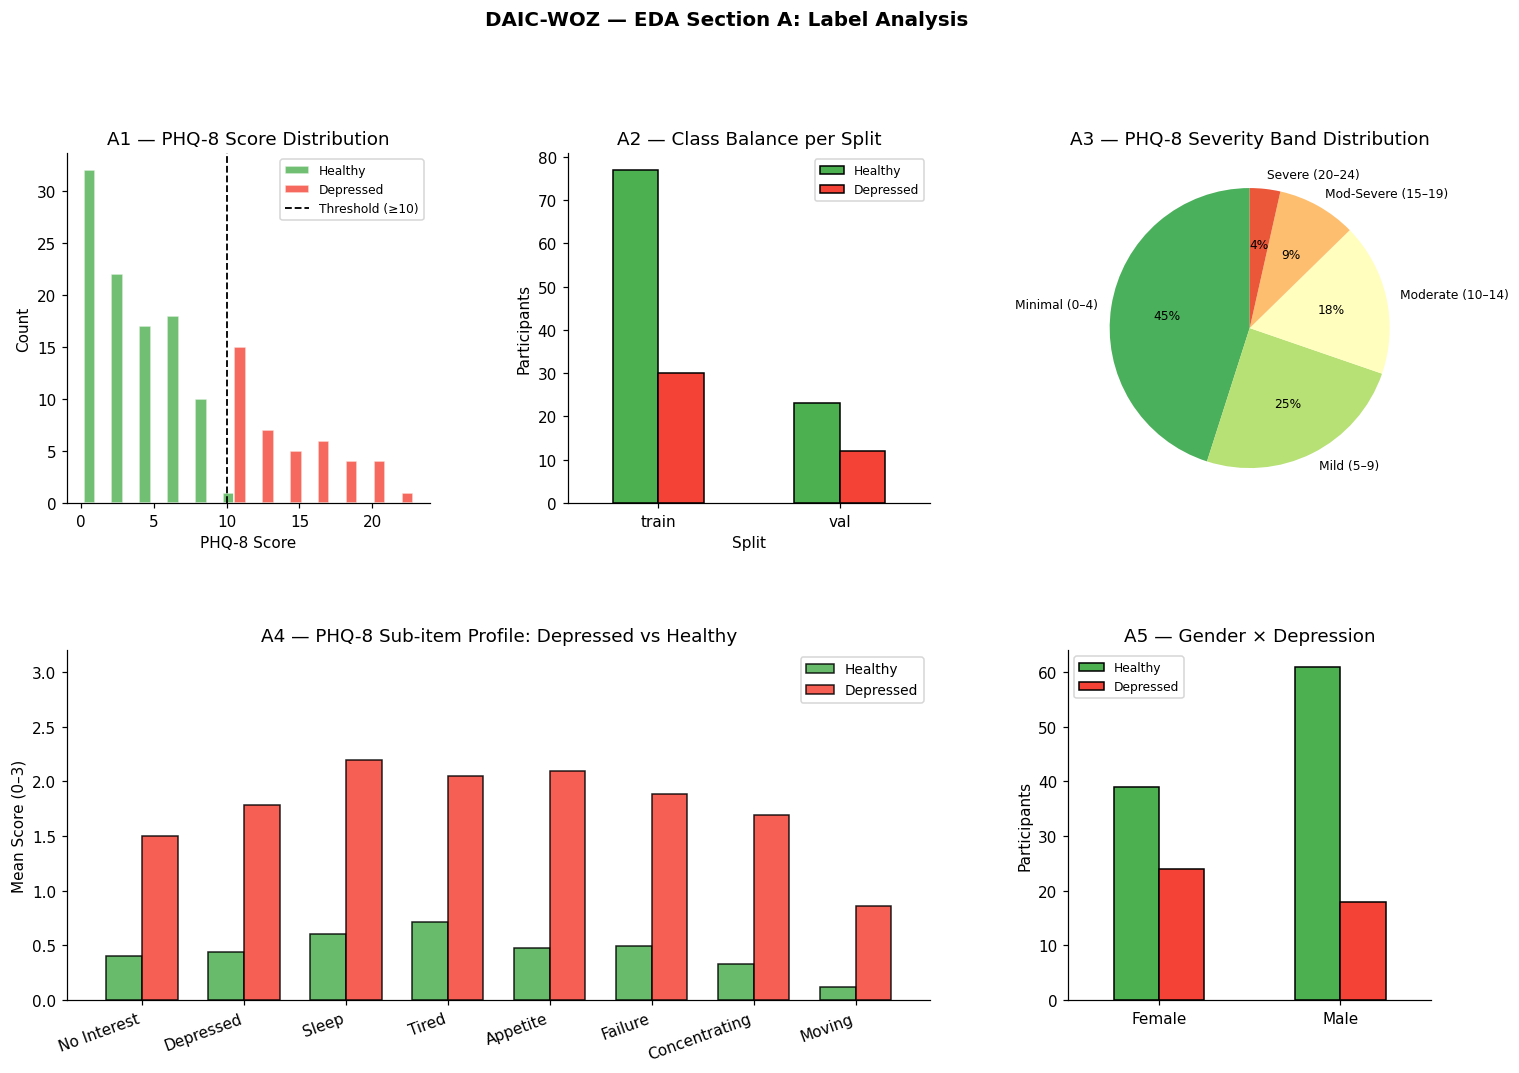


✓ EDA Section A complete


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

# ── Load all three splits to a combined label DataFrame ───────────────────────
LABEL_COLS = [
    "Participant_ID","PHQ8_Binary","PHQ8_Score","Gender",
    "PHQ8_NoInterest","PHQ8_Depressed","PHQ8_Sleep","PHQ8_Tired",
    "PHQ8_Appetite","PHQ8_Failure","PHQ8_Concentrating","PHQ8_Moving"
]
df_train_lbl = pd.read_csv(TRAIN_CSV)[LABEL_COLS].assign(split="train")
df_dev_lbl   = pd.read_csv(DEV_CSV)[LABEL_COLS].assign(split="val")
df_test_lbl  = pd.read_csv(TEST_CSV).assign(split="test")

# ── A1 — Basic stats ──────────────────────────────────────────────────────────
all_lbl = pd.concat([df_train_lbl, df_dev_lbl], ignore_index=True)  # exclude unlabelled test

print("=" * 50)
print("  A1 — Overall Label Statistics (train + val)")
print("=" * 50)
print(f"  Total labelled participants : {len(all_lbl)}")
print(f"  Depressed  (PHQ8_Binary=1) : {(all_lbl.PHQ8_Binary==1).sum()}  "
      f"({100*(all_lbl.PHQ8_Binary==1).mean():.1f}%)")
print(f"  Healthy    (PHQ8_Binary=0) : {(all_lbl.PHQ8_Binary==0).sum()}  "
      f"({100*(all_lbl.PHQ8_Binary==0).mean():.1f}%)")
print(f"\n  PHQ-8 Score — mean : {all_lbl.PHQ8_Score.mean():.2f} "
      f"  std : {all_lbl.PHQ8_Score.std():.2f} "
      f"  range : {int(all_lbl.PHQ8_Score.min())}–{int(all_lbl.PHQ8_Score.max())}")
print(f"\n  Gender distribution (train+val):")
print(all_lbl.groupby(["Gender","PHQ8_Binary"])["Participant_ID"]
      .count().unstack(fill_value=0)
      .rename(index={0:"Female",1:"Male"}, columns={0:"Not Dep",1:"Depressed"}))

# ── A2 — Severity band analysis ───────────────────────────────────────────────
def phq_band(score):
    if   score <= 4:  return "Minimal (0–4)"
    elif score <= 9:  return "Mild (5–9)"
    elif score <= 14: return "Moderate (10–14)"
    elif score <= 19: return "Mod-Severe (15–19)"
    else:             return "Severe (20–24)"

all_lbl["severity_band"] = all_lbl["PHQ8_Score"].apply(phq_band)
band_order = ["Minimal (0–4)","Mild (5–9)","Moderate (10–14)","Mod-Severe (15–19)","Severe (20–24)"]
band_counts = all_lbl["severity_band"].value_counts().reindex(band_order, fill_value=0)

# ── A3 — PHQ sub-item profiles (depressed vs healthy) ─────────────────────────
SUB_ITEMS = ["PHQ8_NoInterest","PHQ8_Depressed","PHQ8_Sleep","PHQ8_Tired",
             "PHQ8_Appetite","PHQ8_Failure","PHQ8_Concentrating","PHQ8_Moving"]
sub_labels = ["No Interest","Depressed","Sleep","Tired",
              "Appetite","Failure","Concentrating","Moving"]

dep_means   = all_lbl[all_lbl.PHQ8_Binary==1][SUB_ITEMS].mean()
healthy_means = all_lbl[all_lbl.PHQ8_Binary==0][SUB_ITEMS].mean()

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# [0,0] PHQ-8 score histogram
ax1 = fig.add_subplot(gs[0, 0])
colors = [("#F44336" if b == 1 else "#4CAF50") for b in all_lbl["PHQ8_Binary"]]
ax1.hist([all_lbl[all_lbl.PHQ8_Binary==0]["PHQ8_Score"],
          all_lbl[all_lbl.PHQ8_Binary==1]["PHQ8_Score"]],
         bins=12, color=["#4CAF50","#F44336"], label=["Healthy","Depressed"],
         edgecolor="white", stacked=False, alpha=0.8)
ax1.axvline(10, color="black", linestyle="--", linewidth=1.2, label="Threshold (≥10)")
ax1.set_xlabel("PHQ-8 Score");  ax1.set_ylabel("Count")
ax1.set_title("A1 — PHQ-8 Score Distribution"); ax1.legend(fontsize=8)

# [0,1] Binary label per split
ax2 = fig.add_subplot(gs[0, 1])
split_balance = (pd.concat([df_train_lbl, df_dev_lbl])
                 .groupby(["split","PHQ8_Binary"])["Participant_ID"].count()
                 .unstack(fill_value=0).rename(columns={0:"Healthy",1:"Depressed"}))
split_balance.plot(kind="bar", ax=ax2, color=["#4CAF50","#F44336"],
                   edgecolor="black", rot=0)
ax2.set_title("A2 — Class Balance per Split"); ax2.set_xlabel("Split")
ax2.set_ylabel("Participants"); ax2.legend(fontsize=8)

# [0,2] Severity band pie
ax3 = fig.add_subplot(gs[0, 2])
ax3.pie(band_counts.values, labels=band_counts.index, autopct="%1.0f%%",
        colors=sns.color_palette("RdYlGn_r", len(band_counts)),
        startangle=90, textprops={"fontsize": 8})
ax3.set_title("A3 — PHQ-8 Severity Band Distribution")

# [1,0:2] Sub-item radar / grouped bar
ax4 = fig.add_subplot(gs[1, :2])
x   = range(len(sub_labels))
w   = 0.35
ax4.bar([i - w/2 for i in x], healthy_means.values, w,
        label="Healthy",   color="#4CAF50", edgecolor="black", alpha=0.85)
ax4.bar([i + w/2 for i in x], dep_means.values,     w,
        label="Depressed", color="#F44336", edgecolor="black", alpha=0.85)
ax4.set_xticks(list(x)); ax4.set_xticklabels(sub_labels, rotation=20, ha="right")
ax4.set_ylabel("Mean Score (0–3)"); ax4.set_title("A4 — PHQ-8 Sub-item Profile: Depressed vs Healthy")
ax4.legend(fontsize=9); ax4.set_ylim(0, 3.2)

# [1,2] Gender × depression
ax5 = fig.add_subplot(gs[1, 2])
gender_dep = (all_lbl.groupby(["Gender","PHQ8_Binary"])["Participant_ID"]
              .count().unstack(fill_value=0)
              .rename(index={0:"Female",1:"Male"}, columns={0:"Healthy",1:"Depressed"}))
gender_dep.plot(kind="bar", ax=ax5, color=["#4CAF50","#F44336"],
                edgecolor="black", rot=0)
ax5.set_title("A5 — Gender × Depression"); ax5.set_xlabel("")
ax5.set_ylabel("Participants"); ax5.legend(fontsize=8)

plt.suptitle("DAIC-WOZ — EDA Section A: Label Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.show()

print("\n✓ EDA Section A complete")

## EDA Section B — Session-Level Statistics (Length, Duration, Modality Completeness)

How long are each participant's sessions? Are all modality files present?  
This explains why **statistical aggregation** is the right approach for a fixed-length model input.

Scanning sessions:   0%|          | 0/142 [00:00<?, ?it/s]

B1 — Modality File Availability (% of participants):
  COVAREP         97.9%  ███████████████████
  FORMANT         97.9%  ███████████████████
  CLNF_AUs        97.9%  ███████████████████
  CLNF_pose       97.9%  ███████████████████
  CLNF_gaze       97.9%  ███████████████████
  TRANSCRIPT      97.9%  ███████████████████

B2 — COVAREP Audio Duration:
  Mean  : 15.7 min  |  Std : 4.4 min
  Min   : 6.9 min  |  Max : 32.8 min

    Transcript Session Span:
  Mean  : 14.8 min  |  Max : 31.9 min


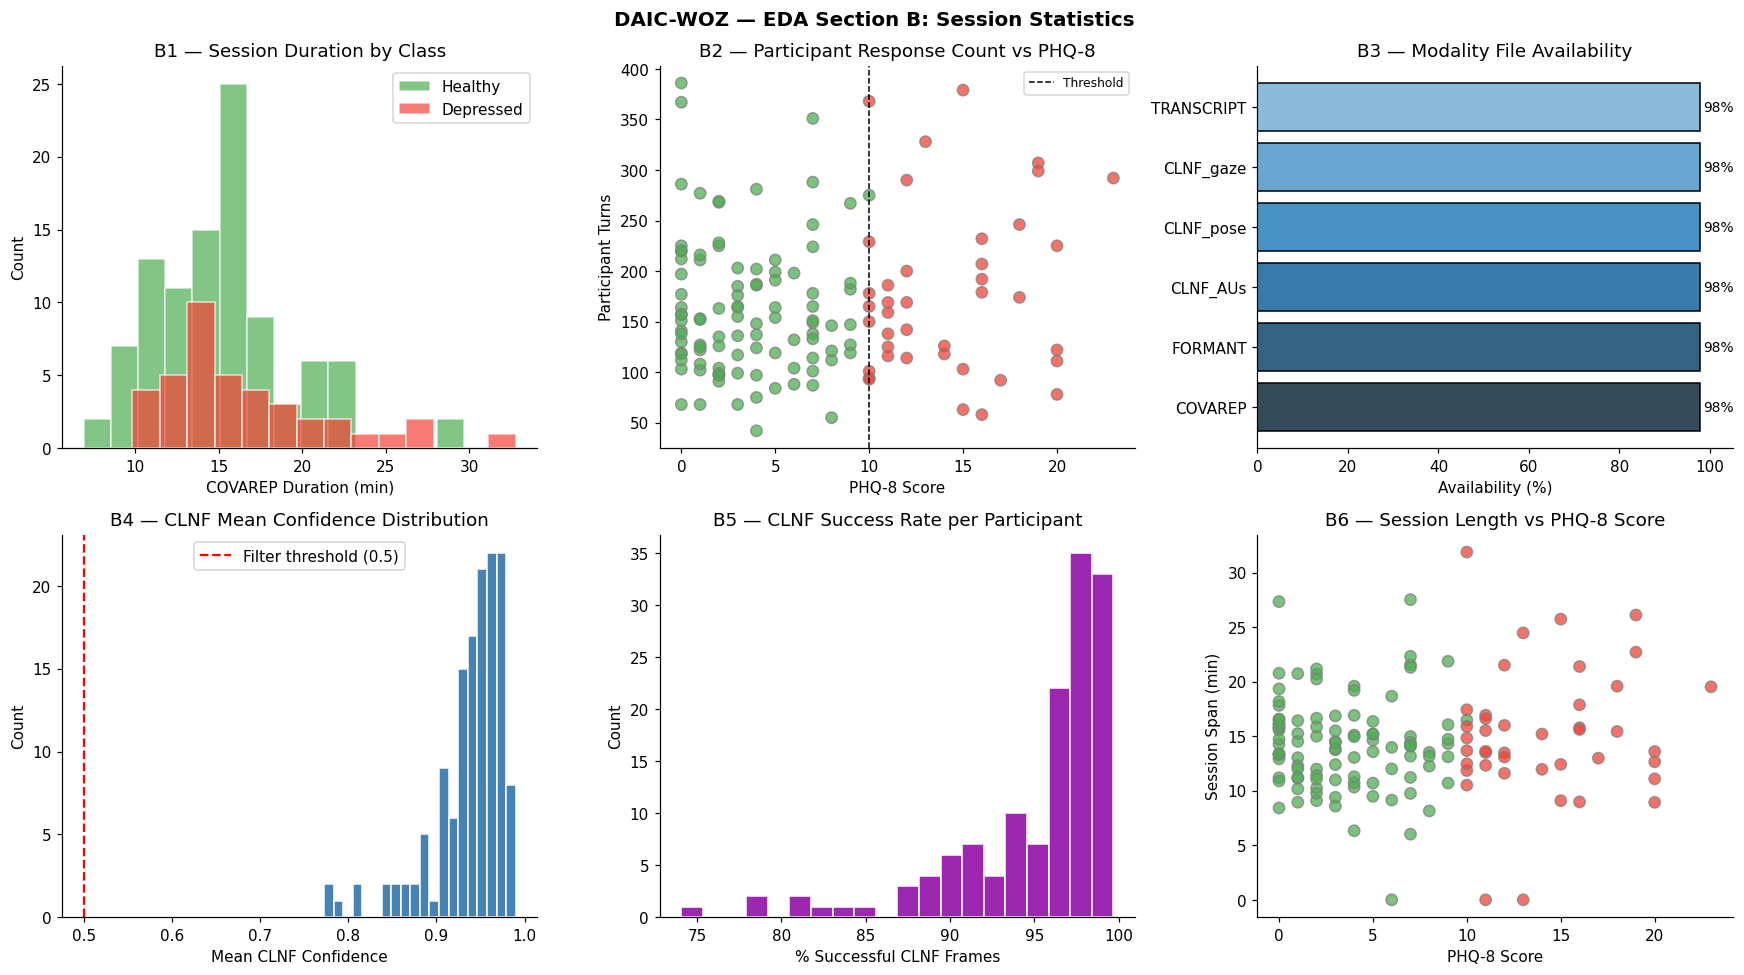

✓ EDA Section B complete


In [9]:
from tqdm.notebook import tqdm

# ── Gather per-participant file stats ──────────────────────────────────────────
all_pids_lbl = pd.concat([df_train_lbl, df_dev_lbl])["Participant_ID"].astype(int).tolist()

MODALITY_FILES = {
    "COVAREP"  : "_COVAREP.csv",
    "FORMANT"  : "_FORMANT.csv",
    "CLNF_AUs" : "_CLNF_AUs.txt",
    "CLNF_pose": "_CLNF_pose.txt",
    "CLNF_gaze": "_CLNF_gaze.txt",
    "TRANSCRIPT": "_TRANSCRIPT.csv",
}

session_stats = []
for pid in tqdm(all_pids_lbl, desc="Scanning sessions"):
    row = {"Participant_ID": pid}
    # COVAREP → number of frames (proxy for audio duration)
    cov_path = os.path.join(DATA_DIR, f"{pid}_COVAREP.csv")
    if os.path.exists(cov_path):
        cov_df = pd.read_csv(cov_path, header=None)
        row["covarep_frames"]   = len(cov_df)
        row["covarep_duration_s"] = len(cov_df) / 100.0   # ~100 Hz frame rate
    else:
        row["covarep_frames"]   = None
        row["covarep_duration_s"] = None

    # CLNF_AUs → frame count and mean confidence
    au_path = os.path.join(DATA_DIR, f"{pid}_CLNF_AUs.txt")
    if os.path.exists(au_path):
        au_df = pd.read_csv(au_path)
        au_df.columns = au_df.columns.str.strip()
        row["au_frames"]      = len(au_df)
        row["au_mean_conf"]   = au_df["confidence"].mean()
        row["au_pct_success"] = (au_df["success"] == 1).mean() * 100
    else:
        row["au_frames"] = row["au_mean_conf"] = row["au_pct_success"] = None

    # TRANSCRIPT → total turns, participant turns, session span
    tx_path = os.path.join(DATA_DIR, f"{pid}_TRANSCRIPT.csv")
    if os.path.exists(tx_path):
        tx_df = pd.read_csv(tx_path, sep="\t")
        tx_df.columns = tx_df.columns.str.strip().str.lower()
        row["total_turns"]       = len(tx_df)
        ptcp_rows = tx_df[tx_df["speaker"].str.strip().str.lower() == "participant"]
        row["participant_turns"] = len(ptcp_rows)
        row["session_span_s"]    = float(tx_df["stop_time"].max() - tx_df["start_time"].min()) \
                                   if len(tx_df) > 0 else None
    else:
        row["total_turns"] = row["participant_turns"] = row["session_span_s"] = None

    # Modality presence flags
    for mod, suffix in MODALITY_FILES.items():
        row[f"has_{mod}"] = os.path.exists(os.path.join(DATA_DIR, f"{pid}{suffix}"))

    session_stats.append(row)

sess_df = pd.DataFrame(session_stats).merge(
    pd.concat([df_train_lbl, df_dev_lbl])[["Participant_ID","PHQ8_Binary","PHQ8_Score","split"]],
    on="Participant_ID", how="left"
)

# ── B1 — Modality completeness heatmap ────────────────────────────────────────
has_cols = [f"has_{m}" for m in MODALITY_FILES]
completeness = sess_df[has_cols].mean() * 100

print("B1 — Modality File Availability (% of participants):")
for col, pct in zip(MODALITY_FILES.keys(), completeness):
    bar = "█" * int(pct / 5)
    print(f"  {col:<14} {pct:5.1f}%  {bar}")

# ── B2 — Session duration distribution ────────────────────────────────────────
dur = sess_df["covarep_duration_s"].dropna()
span = sess_df["session_span_s"].dropna()

print(f"\nB2 — COVAREP Audio Duration:")
print(f"  Mean  : {dur.mean()/60:.1f} min  |  Std : {dur.std()/60:.1f} min")
print(f"  Min   : {dur.min()/60:.1f} min  |  Max : {dur.max()/60:.1f} min")

print(f"\n    Transcript Session Span:")
print(f"  Mean  : {span.mean()/60:.1f} min  |  Max : {span.max()/60:.1f} min")

# ── Figures ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("DAIC-WOZ — EDA Section B: Session Statistics", fontsize=13, fontweight="bold")

# [0,0] Frame count distribution (depressed vs healthy)
for label, col, grp in [(0,"#4CAF50","Healthy"), (1,"#F44336","Depressed")]:
    subset = sess_df[sess_df["PHQ8_Binary"]==label]["covarep_duration_s"].dropna() / 60
    axes[0,0].hist(subset, bins=14, alpha=0.7, color=col, edgecolor="white", label=grp)
axes[0,0].set_xlabel("COVAREP Duration (min)"); axes[0,0].set_ylabel("Count")
axes[0,0].set_title("B1 — Session Duration by Class"); axes[0,0].legend()

# [0,1] Participant turn count vs PHQ-8 score
axes[0,1].scatter(sess_df["PHQ8_Score"], sess_df["participant_turns"],
                  c=sess_df["PHQ8_Binary"].map({0:"#4CAF50",1:"#F44336"}),
                  alpha=0.75, edgecolors="grey", s=55)
axes[0,1].set_xlabel("PHQ-8 Score"); axes[0,1].set_ylabel("Participant Turns")
axes[0,1].set_title("B2 — Participant Response Count vs PHQ-8")
axes[0,1].axvline(10, linestyle="--", color="black", lw=1, label="Threshold")
axes[0,1].legend(fontsize=8)

# [0,2] Modality completeness bar
axes[0,2].barh(list(MODALITY_FILES.keys()), completeness.values,
               color=sns.color_palette("Blues_d", len(MODALITY_FILES))[::-1], edgecolor="black")
axes[0,2].set_xlim(0, 105); axes[0,2].set_xlabel("Availability (%)")
axes[0,2].set_title("B3 — Modality File Availability")
for i, v in enumerate(completeness.values):
    axes[0,2].text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9)

# [1,0] CLNF confidence distribution
conf_data = sess_df["au_mean_conf"].dropna()
axes[1,0].hist(conf_data, bins=20, color="steelblue", edgecolor="white")
axes[1,0].axvline(0.5, color="red", linestyle="--", label="Filter threshold (0.5)")
axes[1,0].set_xlabel("Mean CLNF Confidence"); axes[1,0].set_ylabel("Count")
axes[1,0].set_title("B4 — CLNF Mean Confidence Distribution"); axes[1,0].legend()

# [1,1] % successful CLNF frames per participant
axes[1,1].hist(sess_df["au_pct_success"].dropna(), bins=20, color="#9C27B0", edgecolor="white")
axes[1,1].set_xlabel("% Successful CLNF Frames"); axes[1,1].set_ylabel("Count")
axes[1,1].set_title("B5 — CLNF Success Rate per Participant")

# [1,2] Session duration vs PHQ-8 score (scatter)
axes[1,2].scatter(sess_df["PHQ8_Score"], sess_df["session_span_s"].fillna(0)/60,
                  c=sess_df["PHQ8_Binary"].map({0:"#4CAF50",1:"#F44336"}),
                  alpha=0.75, edgecolors="grey", s=55)
axes[1,2].set_xlabel("PHQ-8 Score"); axes[1,2].set_ylabel("Session Span (min)")
axes[1,2].set_title("B6 — Session Length vs PHQ-8 Score")

plt.tight_layout()
plt.show()
print("✓ EDA Section B complete")

## EDA Section C — COVAREP Acoustic Feature Analysis

Explore the raw acoustic signal statistics: **F0 (pitch)**, **voiced frame ratio**, and key prosodic coefficients.  
Depressed speakers show characteristic **flatter pitch (lower F0 variance)**, **lower voiced ratio**, and altered energy patterns — these are the key depression biomarkers captured by COVAREP.

C1 — Voiced F0 Mean by Class:
            f0_mean_voiced         f0_std_voiced         f0_range_voiced  \
                      mean     std          mean     std            mean   
PHQ8_Binary                                                                
Healthy           150.2910 39.1110       38.8210  8.2330        216.1820   
Depressed         165.6870 40.0340       41.4000 11.0810        243.9620   

                    voiced_ratio         
                std         mean    std  
PHQ8_Binary                              
Healthy     58.9440       0.3650 0.0870  
Depressed   60.9190       0.3670 0.0830  


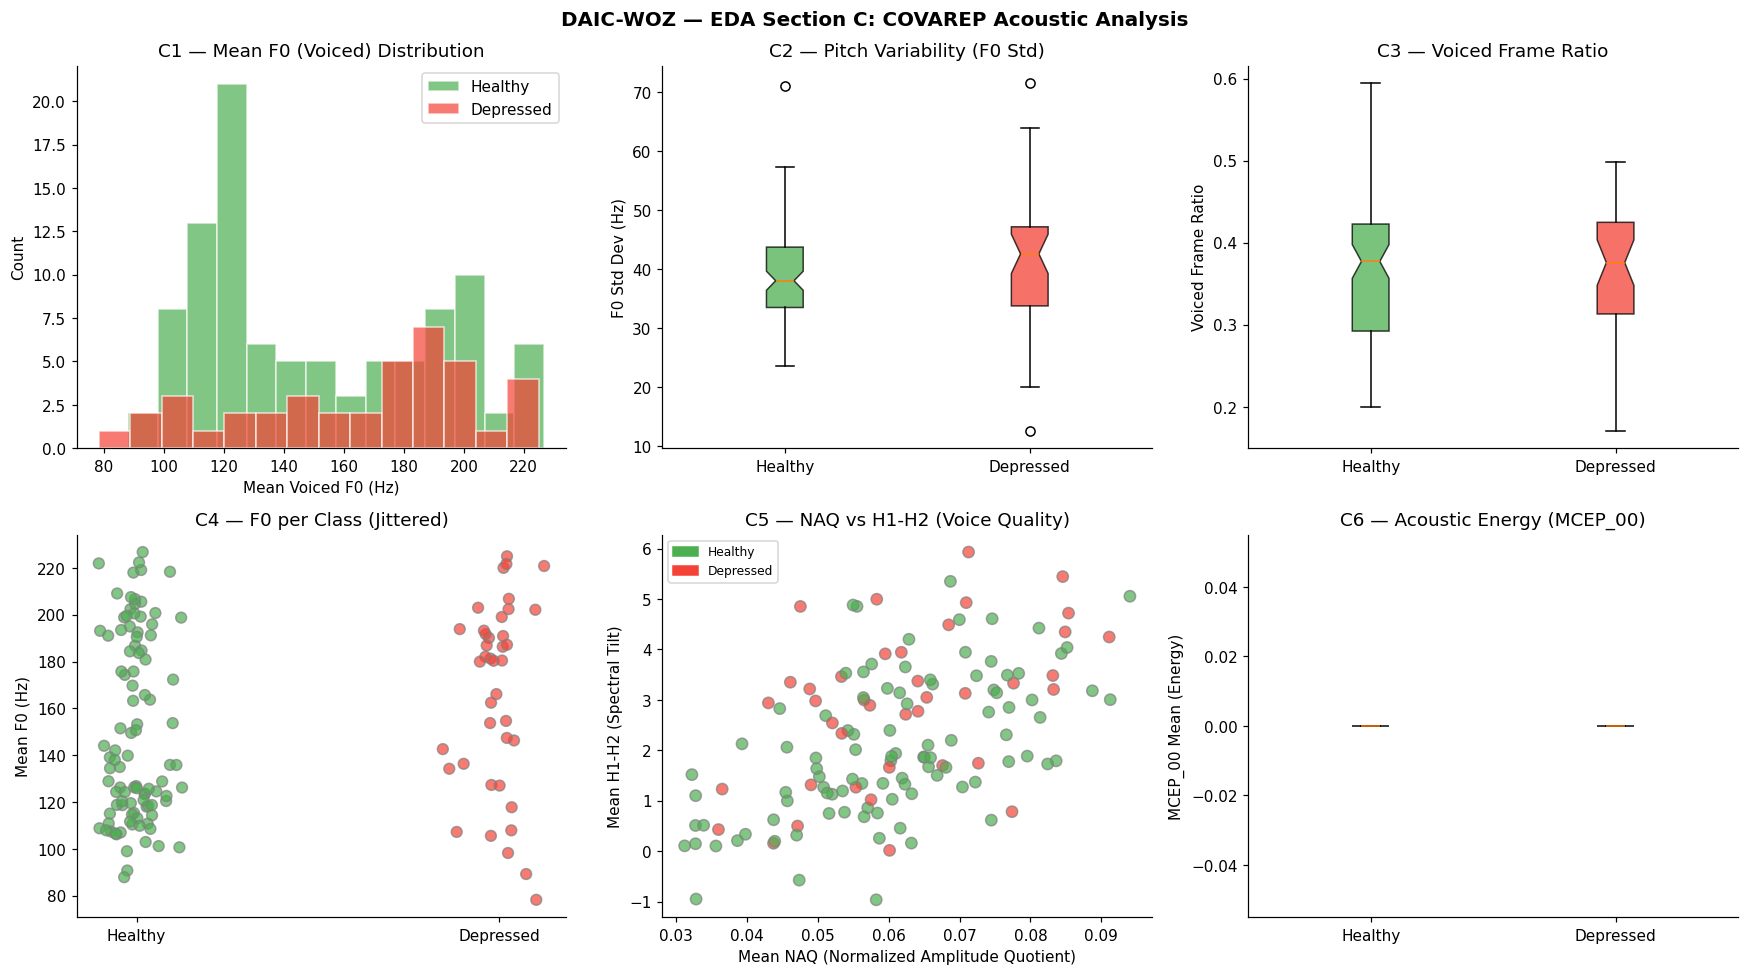


C3 — Mean COVAREP stat correlation with PHQ8_Binary:
h1h2_mean         0.2580
f0_range_voiced   0.2080
f0_mean_voiced    0.1760
peakSlope_mean    0.1620
f0_std_voiced     0.1280
naq_mean          0.0440
voiced_ratio      0.0090
mcep0_mean           NaN
Name: PHQ8_Binary, dtype: float64

✓ EDA Section C complete


In [10]:
# ── Compute per-participant COVAREP summary stats for labelled sessions ────────
COVAREP_COLS_LOCAL = (
    ["F0", "VUV", "NAQ", "QOQ", "H1H2", "PSP", "MDQ", "peakSlope", "Rd", "Rd_conf"]
    + [f"MCEP_{i:02d}"  for i in range(25)]
    + [f"HMPDM_{i:02d}" for i in range(24)]
    + [f"HMPDD_{i:02d}" for i in range(14)]
    + ["HMPDD_14"]
)[:74]

cov_eda_records = []
for pid, label, split in zip(
        sess_df["Participant_ID"], sess_df["PHQ8_Binary"], sess_df["split"]):
    path = os.path.join(DATA_DIR, f"{int(pid)}_COVAREP.csv")
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path, header=None)
    df.columns = COVAREP_COLS_LOCAL[:df.shape[1]]
    voiced = df[df["VUV"] > 0]
    f0_vals = voiced["F0"].values if len(voiced) > 0 else np.array([np.nan])
    cov_eda_records.append({
        "Participant_ID"  : pid,
        "PHQ8_Binary"     : label,
        "split"           : split,
        "f0_mean_voiced"  : np.nanmean(f0_vals),
        "f0_std_voiced"   : np.nanstd(f0_vals),
        "f0_range_voiced" : np.nanmax(f0_vals) - np.nanmin(f0_vals) if len(f0_vals) > 1 else 0.0,
        "voiced_ratio"    : len(voiced) / len(df) if len(df) > 0 else 0.0,
        "naq_mean"        : df["NAQ"].mean() if "NAQ" in df.columns else np.nan,
        "h1h2_mean"       : df["H1H2"].mean() if "H1H2" in df.columns else np.nan,
        "peakSlope_mean"  : df["peakSlope"].mean() if "peakSlope" in df.columns else np.nan,
        "mcep0_mean"      : df["MCEP_00"].mean() if "MCEP_00" in df.columns else np.nan,
    })

cov_eda = pd.DataFrame(cov_eda_records)

# ── C1 — Print quick stats ─────────────────────────────────────────────────────
print("C1 — Voiced F0 Mean by Class:")
print(cov_eda.groupby("PHQ8_Binary")[["f0_mean_voiced","f0_std_voiced",
                                       "f0_range_voiced","voiced_ratio"]]
      .agg(["mean","std"]).round(3).rename(index={0:"Healthy",1:"Depressed"}))

# ── C2 — Figures ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("DAIC-WOZ — EDA Section C: COVAREP Acoustic Analysis", fontsize=13, fontweight="bold")

palette = {0: "#4CAF50", 1: "#F44336"}
label_map = {0: "Healthy", 1: "Depressed"}

# [0,0] F0 mean (voiced frames) — distribution per class
for cls in [0, 1]:
    data = cov_eda[cov_eda["PHQ8_Binary"]==cls]["f0_mean_voiced"].dropna()
    axes[0,0].hist(data, bins=14, alpha=0.7, color=palette[cls],
                   edgecolor="white", label=label_map[cls])
axes[0,0].set_xlabel("Mean Voiced F0 (Hz)"); axes[0,0].set_ylabel("Count")
axes[0,0].set_title("C1 — Mean F0 (Voiced) Distribution"); axes[0,0].legend()

# [0,1] F0 std (pitch variability) — boxplot
cov_box_data = [
    cov_eda[cov_eda["PHQ8_Binary"]==0]["f0_std_voiced"].dropna().values,
    cov_eda[cov_eda["PHQ8_Binary"]==1]["f0_std_voiced"].dropna().values,
]
bp = axes[0,1].boxplot(cov_box_data, patch_artist=True, notch=True,
                        labels=["Healthy","Depressed"])
for patch, col in zip(bp["boxes"], ["#4CAF50","#F44336"]):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[0,1].set_ylabel("F0 Std Dev (Hz)"); axes[0,1].set_title("C2 — Pitch Variability (F0 Std)")

# [0,2] Voiced ratio per class
vr_box = [
    cov_eda[cov_eda["PHQ8_Binary"]==0]["voiced_ratio"].dropna().values,
    cov_eda[cov_eda["PHQ8_Binary"]==1]["voiced_ratio"].dropna().values,
]
bp2 = axes[0,2].boxplot(vr_box, patch_artist=True, notch=True, labels=["Healthy","Depressed"])
for patch, col in zip(bp2["boxes"], ["#4CAF50","#F44336"]):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[0,2].set_ylabel("Voiced Frame Ratio"); axes[0,2].set_title("C3 — Voiced Frame Ratio")

# [1,0] F0 mean vs PHQ-8 score (scatter)
axes[1,0].scatter(cov_eda["PHQ8_Binary"].map({0:0,1:1}) + np.random.normal(0,0.05,len(cov_eda)),
                  cov_eda["f0_mean_voiced"],
                  c=cov_eda["PHQ8_Binary"].map(palette),
                  alpha=0.7, edgecolors="grey", s=50)
axes[1,0].set_xticks([0,1]); axes[1,0].set_xticklabels(["Healthy","Depressed"])
axes[1,0].set_ylabel("Mean F0 (Hz)"); axes[1,0].set_title("C4 — F0 per Class (Jittered)")

# [1,1] NAQ and H1H2 (voice quality markers) — scatter
sc = axes[1,1].scatter(cov_eda["naq_mean"], cov_eda["h1h2_mean"],
                        c=cov_eda["PHQ8_Binary"].map(palette),
                        alpha=0.7, edgecolors="grey", s=55)
axes[1,1].set_xlabel("Mean NAQ (Normalized Amplitude Quotient)")
axes[1,1].set_ylabel("Mean H1-H2 (Spectral Tilt)")
axes[1,1].set_title("C5 — NAQ vs H1-H2 (Voice Quality)")
from matplotlib.patches import Patch
axes[1,1].legend(handles=[Patch(color="#4CAF50",label="Healthy"),
                           Patch(color="#F44336",label="Depressed")], fontsize=8)

# [1,2] MCEP_00 (energy) per class
mcep_box = [
    cov_eda[cov_eda["PHQ8_Binary"]==0]["mcep0_mean"].dropna().values,
    cov_eda[cov_eda["PHQ8_Binary"]==1]["mcep0_mean"].dropna().values,
]
bp3 = axes[1,2].boxplot(mcep_box, patch_artist=True, notch=True, labels=["Healthy","Depressed"])
for patch, col in zip(bp3["boxes"], ["#4CAF50","#F44336"]):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[1,2].set_ylabel("MCEP_00 Mean (Energy)"); axes[1,2].set_title("C6 — Acoustic Energy (MCEP_00)")

plt.tight_layout()
plt.show()

# ── C3 — Correlation of COVAREP features across 5 sample participants ──────────
print("\nC3 — Mean COVAREP stat correlation with PHQ8_Binary:")
cols_of_interest = ["f0_mean_voiced","f0_std_voiced","f0_range_voiced",
                     "voiced_ratio","naq_mean","h1h2_mean","peakSlope_mean","mcep0_mean"]
corr_with_label = cov_eda[cols_of_interest + ["PHQ8_Binary"]].corr()["PHQ8_Binary"].drop("PHQ8_Binary")
print(corr_with_label.sort_values(key=abs, ascending=False).round(3))
print("\n✓ EDA Section C complete")

## EDA Section D — Formant Analysis (F1–F5)

Formants reflect **vocal tract shape**. F1 correlates with jaw opening; F2 with tongue position. Depression is associated with **lower F1–F2 dispersion** (reduced articulatory precision / mumbling) and narrower formant range.

D1 — Mean Formant Values by Class (Hz):
PHQ8_Binary      Healthy  Depressed
F1_mean         611.3000   623.8000
F2_mean        1594.3000  1587.2000
F3_mean        2527.4000  2524.8000
F4_mean        3445.6000  3450.8000
F5_mean        4346.3000  4348.0000
F2F1_disp_mean  983.4000   963.9000
F3F1_disp_mean 1916.4000  1901.4000


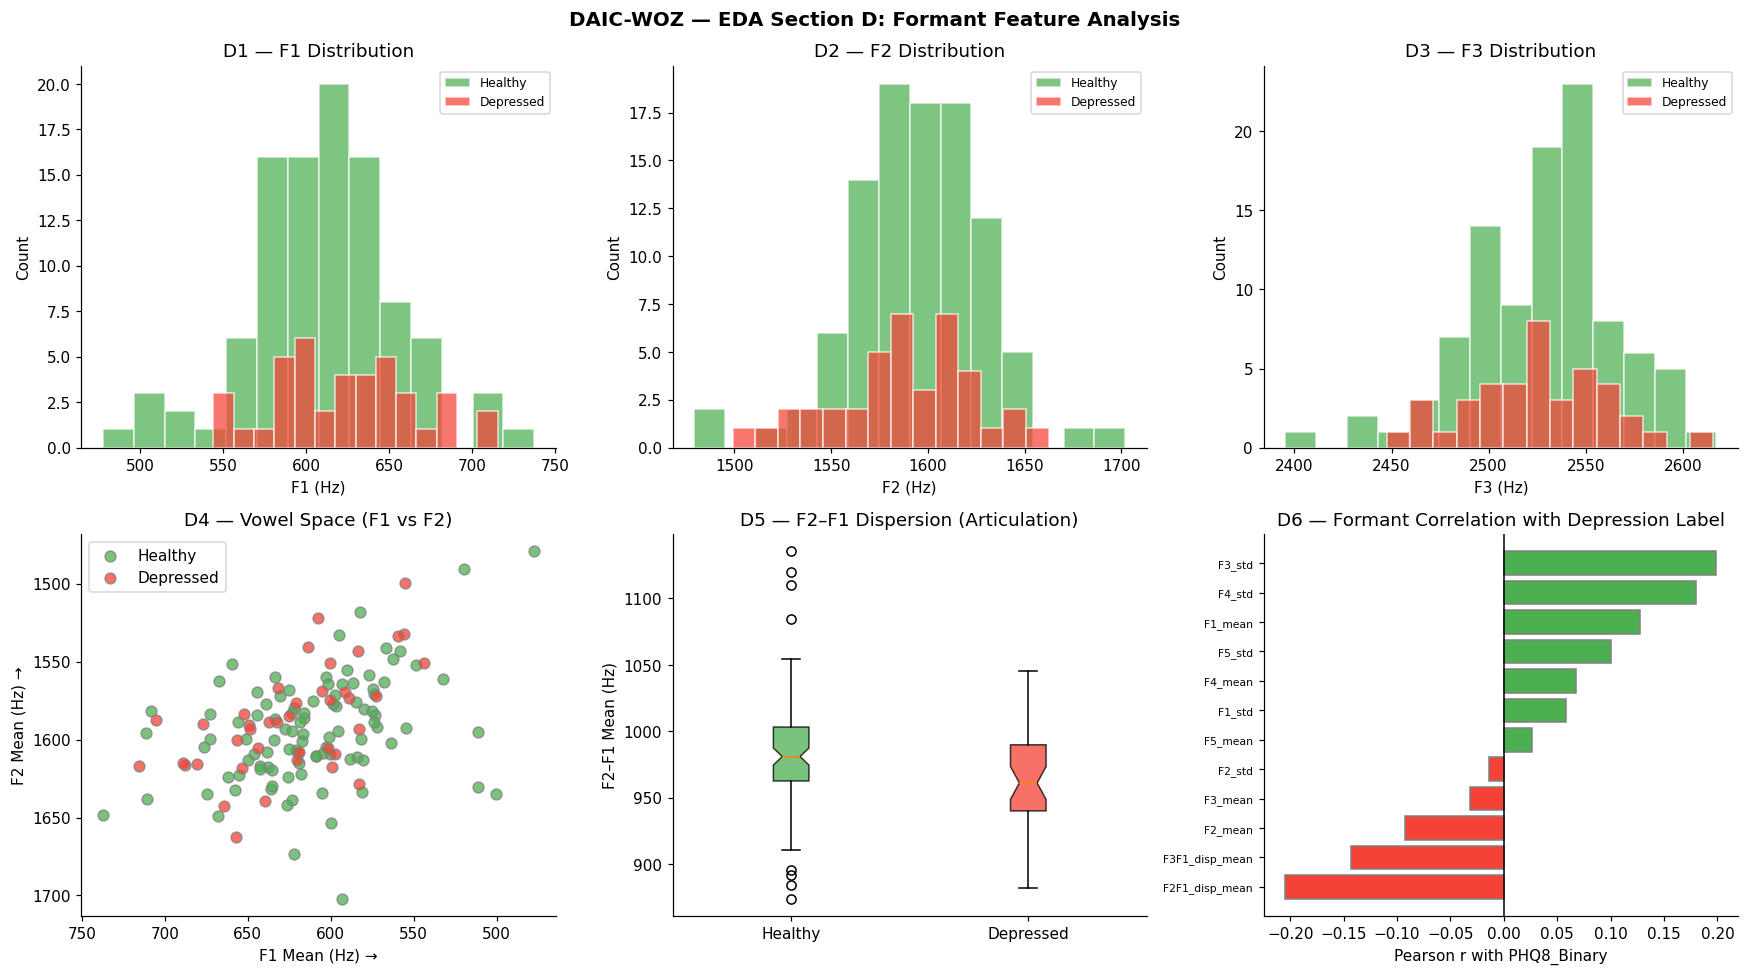

✓ EDA Section D complete


In [11]:
FORMANT_NAMES = ["F1","F2","F3","F4","F5"]

fmnt_eda_records = []
for pid, label in zip(sess_df["Participant_ID"], sess_df["PHQ8_Binary"]):
    path = os.path.join(DATA_DIR, f"{int(pid)}_FORMANT.csv")
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path, header=None, names=FORMANT_NAMES)
    df = df.replace(0, np.nan)
    df[df < 0] = np.nan
    row = {"Participant_ID": pid, "PHQ8_Binary": label}
    for col in FORMANT_NAMES:
        row[f"{col}_mean"] = df[col].mean()
        row[f"{col}_std"]  = df[col].std()
    row["F2F1_disp_mean"] = (df["F2"] - df["F1"]).mean()
    row["F3F1_disp_mean"] = (df["F3"] - df["F1"]).mean()
    fmnt_eda_records.append(row)

fmnt_eda = pd.DataFrame(fmnt_eda_records)

# ── D1 — Print stats ───────────────────────────────────────────────────────────
print("D1 — Mean Formant Values by Class (Hz):")
means_by_class = fmnt_eda.groupby("PHQ8_Binary")[
    [f"{f}_mean" for f in FORMANT_NAMES] + ["F2F1_disp_mean","F3F1_disp_mean"]
].mean().round(1)
print(means_by_class.rename(index={0:"Healthy",1:"Depressed"}).T.to_string())

# ── D2 — Figures ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("DAIC-WOZ — EDA Section D: Formant Feature Analysis", fontsize=13, fontweight="bold")

for i, fmnt in enumerate(FORMANT_NAMES[:3]):
    ax = axes[0, i]
    data_h = fmnt_eda[fmnt_eda.PHQ8_Binary==0][f"{fmnt}_mean"].dropna()
    data_d = fmnt_eda[fmnt_eda.PHQ8_Binary==1][f"{fmnt}_mean"].dropna()
    ax.hist(data_h, bins=14, alpha=0.72, color="#4CAF50", edgecolor="white", label="Healthy")
    ax.hist(data_d, bins=14, alpha=0.72, color="#F44336", edgecolor="white", label="Depressed")
    ax.set_xlabel(f"{fmnt} (Hz)"); ax.set_ylabel("Count")
    ax.set_title(f"D{i+1} — {fmnt} Distribution"); ax.legend(fontsize=8)

# [1,0] F1 vs F2 scatter (classic vowel space)
axes[1,0].scatter(fmnt_eda[fmnt_eda.PHQ8_Binary==0]["F1_mean"],
                  fmnt_eda[fmnt_eda.PHQ8_Binary==0]["F2_mean"],
                  color="#4CAF50", alpha=0.75, edgecolors="grey", s=50, label="Healthy")
axes[1,0].scatter(fmnt_eda[fmnt_eda.PHQ8_Binary==1]["F1_mean"],
                  fmnt_eda[fmnt_eda.PHQ8_Binary==1]["F2_mean"],
                  color="#F44336", alpha=0.75, edgecolors="grey", s=50, label="Depressed")
# Note: F1 axis inverted (linguist convention)
axes[1,0].invert_xaxis(); axes[1,0].invert_yaxis()
axes[1,0].set_xlabel("F1 Mean (Hz) →"); axes[1,0].set_ylabel("F2 Mean (Hz) →")
axes[1,0].set_title("D4 — Vowel Space (F1 vs F2)"); axes[1,0].legend()

# [1,1] F2–F1 dispersion (articulatory precision)
disp_data = [
    fmnt_eda[fmnt_eda.PHQ8_Binary==0]["F2F1_disp_mean"].dropna().values,
    fmnt_eda[fmnt_eda.PHQ8_Binary==1]["F2F1_disp_mean"].dropna().values,
]
bp = axes[1,1].boxplot(disp_data, patch_artist=True, notch=True, labels=["Healthy","Depressed"])
for patch, col in zip(bp["boxes"], ["#4CAF50","#F44336"]):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[1,1].set_ylabel("F2–F1 Mean (Hz)"); axes[1,1].set_title("D5 — F2–F1 Dispersion (Articulation)")

# [1,2] Correlation of formant features with PHQ8_Binary
form_feat_cols = [f"{f}_mean" for f in FORMANT_NAMES] + \
                 [f"{f}_std" for f in FORMANT_NAMES] + \
                 ["F2F1_disp_mean","F3F1_disp_mean"]
corr_fmnt = fmnt_eda[form_feat_cols + ["PHQ8_Binary"]].corr()["PHQ8_Binary"].drop("PHQ8_Binary")
corr_fmnt = corr_fmnt.sort_values(ascending=True)
colors_bar = ["#F44336" if v < 0 else "#4CAF50" for v in corr_fmnt.values]
axes[1,2].barh(range(len(corr_fmnt)), corr_fmnt.values, color=colors_bar, edgecolor="grey")
axes[1,2].set_yticks(range(len(corr_fmnt)))
axes[1,2].set_yticklabels(corr_fmnt.index, fontsize=7)
axes[1,2].axvline(0, color="black", lw=1)
axes[1,2].set_xlabel("Pearson r with PHQ8_Binary")
axes[1,2].set_title("D6 — Formant Correlation with Depression Label")

plt.tight_layout()
plt.show()
print("✓ EDA Section D complete")

## EDA Section E — Facial Action Units, Head Pose & Gaze

Depression manifests visually as **reduced AU12 (smile)**, **elevated AU04 (brow lowerer)**, **gaze aversion** (lower x_0/x_1 variability), and **reduced head movement** (psychomotor retardation).  
This section profiles facial expression differences between depressed and healthy participants.

AU records    : 139
Pose records  : 139
Gaze records  : 139
AU_r columns found in data (14): ['AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU25_r', 'AU26_r']


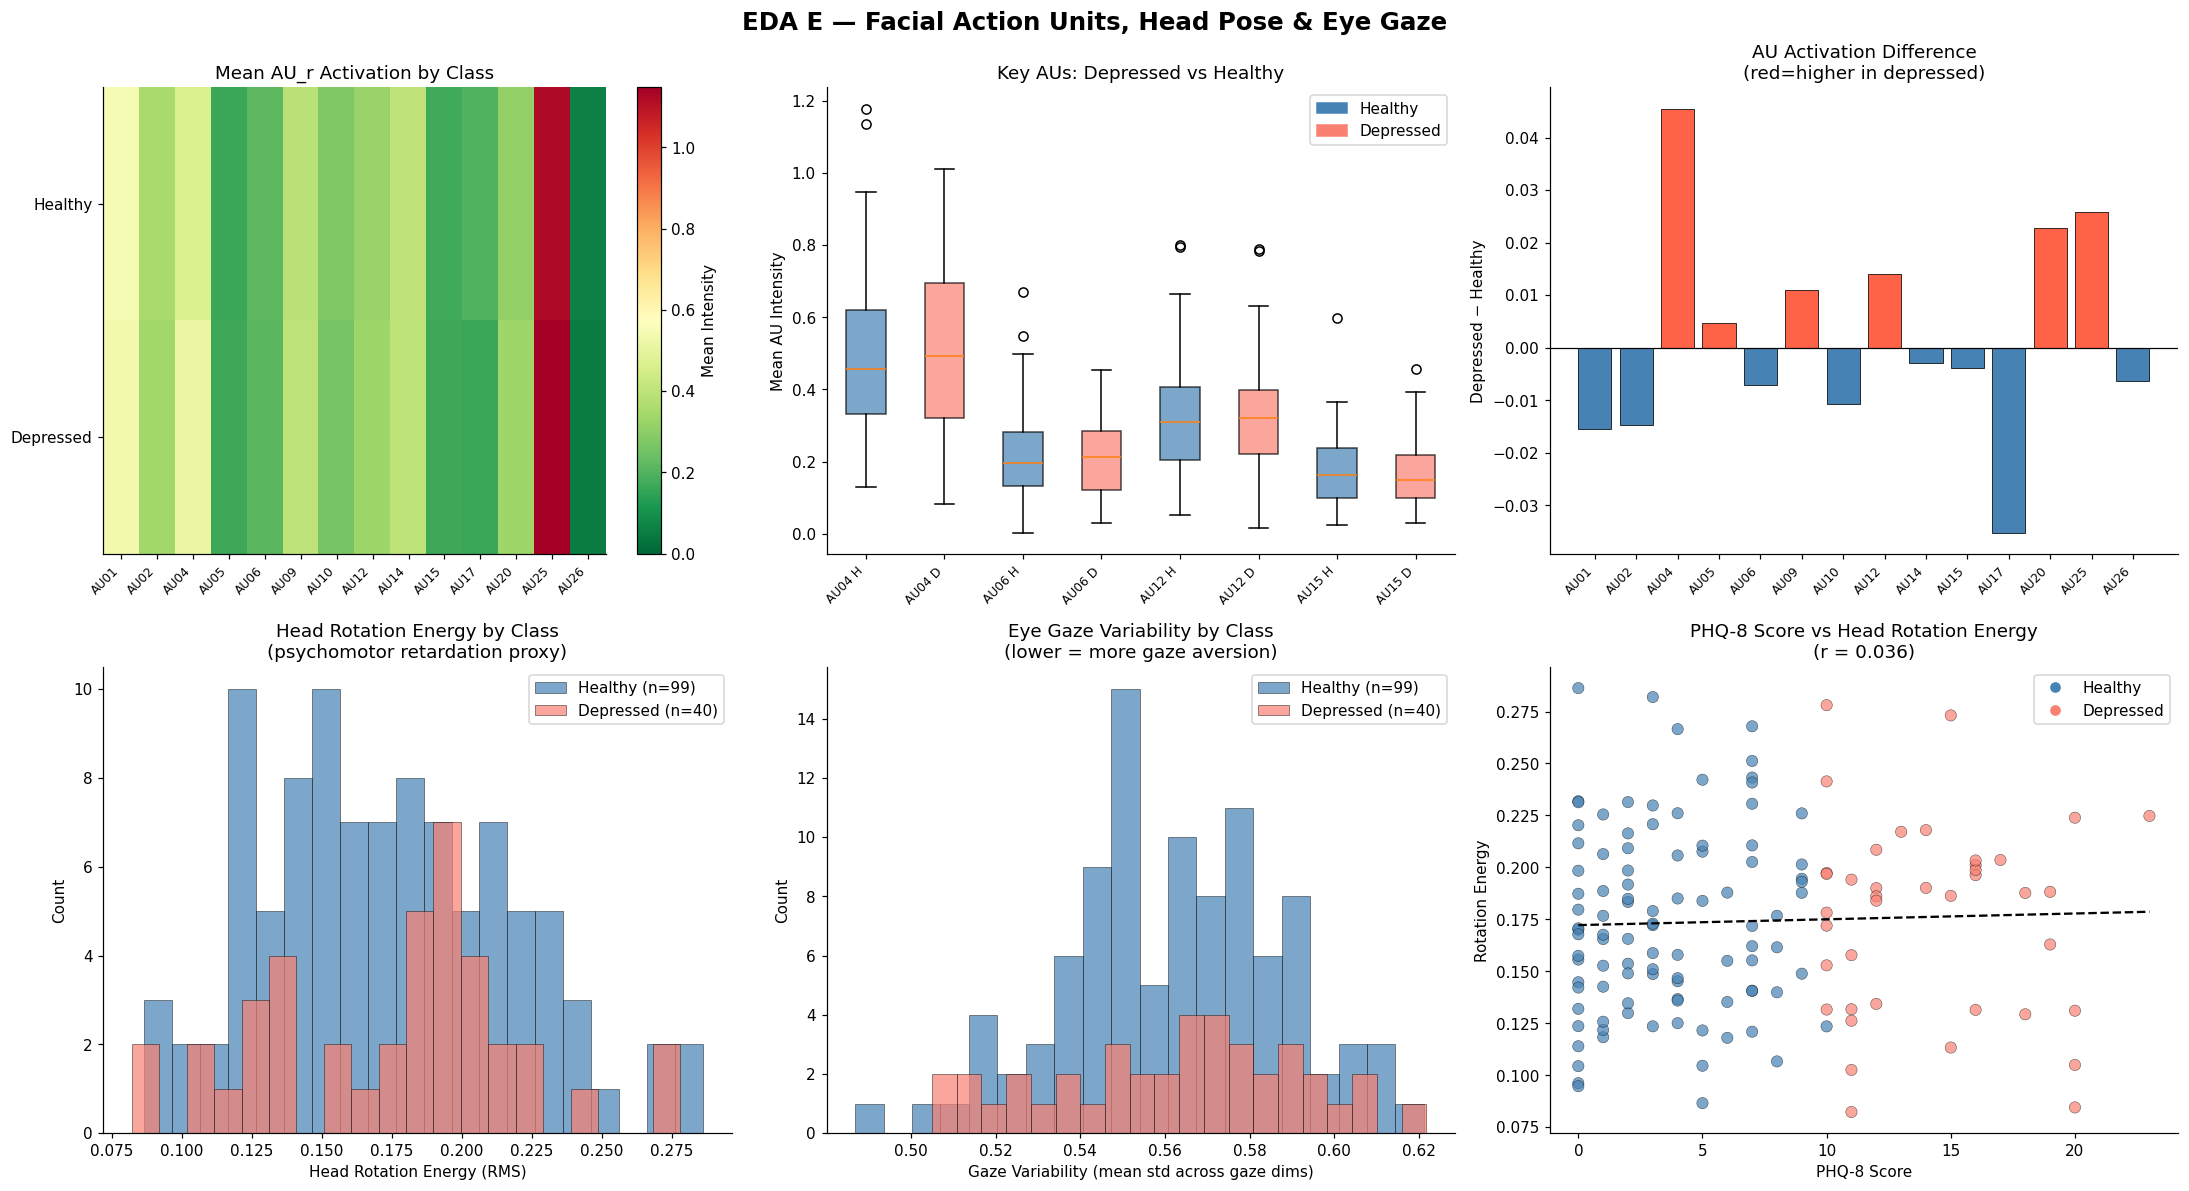

✓ EDA Section E complete — figure saved: eda_e_clnf_analysis.png


In [12]:

# ── EDA E: Facial Action Units, Head Pose & Eye Gaze ──────────────────────────
# Actual AU columns from data (confirmed from file inspection):
AU_R_COLS_EDA = ['AU01_r','AU02_r','AU04_r','AU05_r','AU06_r','AU09_r','AU10_r',
                 'AU12_r','AU14_r','AU15_r','AU17_r','AU20_r','AU25_r','AU26_r']
AU_C_COLS_EDA = ['AU04_c','AU12_c','AU15_c','AU23_c','AU28_c','AU45_c']
POSE_ROT      = ['Rx','Ry','Rz']
GAZE_DIMS     = ['x_0','y_0','z_0','x_1','y_1','z_1']

# Use all_lbl (defined in EDA A) — has Participant_ID, PHQ8_Binary, PHQ8_Score
eda_lbl = all_lbl.copy()

au_records, pose_records, gaze_records = [], [], []

for _, row in eda_lbl.iterrows():
    pid   = int(row['Participant_ID'])
    label = int(row['PHQ8_Binary'])
    score = row.get('PHQ8_Score', np.nan)
    fid   = os.path.join(DATA_DIR, f"{pid}_CLNF_AUs.txt")
    fpid  = os.path.join(DATA_DIR, f"{pid}_CLNF_pose.txt")
    fgid  = os.path.join(DATA_DIR, f"{pid}_CLNF_gaze.txt")

    # ── Action Units ──────────────────────────────────────────────────────────
    if os.path.exists(fid):
        try:
            df_au = pd.read_csv(fid, skipinitialspace=True)
            df_au.columns = df_au.columns.str.strip()
            if 'confidence' in df_au.columns and 'success' in df_au.columns:
                df_au = df_au[(df_au['confidence'] >= 0.5) & (df_au['success'] == 1)]
            rec = {'pid': pid, 'label': label, 'phq_score': score}
            for c in AU_R_COLS_EDA:
                if c in df_au.columns:
                    rec[c] = df_au[c].mean()
            for c in AU_C_COLS_EDA:
                if c in df_au.columns:
                    rec[c + '_occ'] = (df_au[c] > 0).mean()
            au_records.append(rec)
        except Exception:
            pass

    # ── Head Pose ─────────────────────────────────────────────────────────────
    if os.path.exists(fpid):
        try:
            df_p = pd.read_csv(fpid, skipinitialspace=True)
            df_p.columns = df_p.columns.str.strip()
            if 'confidence' in df_p.columns and 'success' in df_p.columns:
                df_p = df_p[(df_p['confidence'] >= 0.5) & (df_p['success'] == 1)]
            rec2 = {'pid': pid, 'label': label, 'phq_score': score}
            for c in POSE_ROT:
                if c in df_p.columns:
                    rec2[c + '_std']  = df_p[c].std()
                    rec2[c + '_mean'] = df_p[c].mean()
            rot_cols = [c for c in POSE_ROT if c in df_p.columns]
            if rot_cols:
                rec2['rot_energy'] = float(np.sqrt((df_p[rot_cols] ** 2).mean(axis=1).mean()))
            pose_records.append(rec2)
        except Exception:
            pass

    # ── Eye Gaze ──────────────────────────────────────────────────────────────
    if os.path.exists(fgid):
        try:
            df_g = pd.read_csv(fgid, skipinitialspace=True)
            df_g.columns = df_g.columns.str.strip()
            if 'confidence' in df_g.columns and 'success' in df_g.columns:
                df_g = df_g[(df_g['confidence'] >= 0.5) & (df_g['success'] == 1)]
            rec3 = {'pid': pid, 'label': label}
            g_present = [c for c in GAZE_DIMS if c in df_g.columns]
            for c in g_present:
                rec3[c + '_std'] = df_g[c].std()
            if g_present:
                rec3['gaze_variability'] = float(df_g[g_present].std(axis=1).mean())
            gaze_records.append(rec3)
        except Exception:
            pass

au_df   = pd.DataFrame(au_records)
pose_df = pd.DataFrame(pose_records)
gaze_df = pd.DataFrame(gaze_records)

print(f"AU records    : {len(au_df)}")
print(f"Pose records  : {len(pose_df)}")
print(f"Gaze records  : {len(gaze_df)}")
if len(au_df) > 0:
    au_r_found = [c for c in AU_R_COLS_EDA if c in au_df.columns]
    print(f"AU_r columns found in data ({len(au_r_found)}): {au_r_found}")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("EDA E — Facial Action Units, Head Pose & Eye Gaze", fontsize=16, fontweight='bold')

au_r_present = [c for c in AU_R_COLS_EDA if c in au_df.columns]

# E1 — AU mean activation heatmap by class
ax = axes[0, 0]
if au_r_present and 'label' in au_df.columns and au_df['label'].nunique() >= 2:
    heat = au_df.groupby('label')[au_r_present].mean()
    heat.index = ['Healthy', 'Depressed']
    im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn_r', vmin=0)
    ax.set_xticks(range(len(au_r_present)))
    ax.set_xticklabels([c.replace('_r','') for c in au_r_present], rotation=45, ha='right', fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Healthy', 'Depressed'])
    fig.colorbar(im, ax=ax, label='Mean Intensity')
    ax.set_title("Mean AU_r Activation by Class")
else:
    ax.text(0.5, 0.5, 'No AU data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("AU Activation Heatmap")

# E2 — Key AUs boxplot
ax = axes[0, 1]
key_aus   = ['AU04_r', 'AU06_r', 'AU12_r', 'AU15_r']
key_aus_p = [c for c in key_aus if c in au_df.columns]
if key_aus_p and 'label' in au_df.columns:
    plot_data, tick_labels, box_colors = [], [], []
    for kau in key_aus_p:
        for lb, clr in zip([0, 1], ['steelblue', 'salmon']):
            vals = au_df[au_df['label'] == lb][kau].dropna().values
            plot_data.append(vals)
            tick_labels.append(f"{kau.replace('_r','')} {'H' if lb==0 else 'D'}")
            box_colors.append(clr)
    bp = ax.boxplot(plot_data, patch_artist=True, labels=tick_labels)
    for patch, clr in zip(bp['boxes'], box_colors):
        patch.set_facecolor(clr); patch.set_alpha(0.7)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel("Mean AU Intensity")
    ax.set_title("Key AUs: Depressed vs Healthy")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='Healthy'), Patch(color='salmon', label='Depressed')])
else:
    ax.text(0.5, 0.5, 'No AU data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Key AU Boxplots")

# E3 — AU difference bar (depressed - healthy)
ax = axes[0, 2]
if au_r_present and 'label' in au_df.columns and au_df['label'].nunique() >= 2:
    grp  = au_df.groupby('label')[au_r_present].mean()
    diff = grp.loc[1] - grp.loc[0]
    clrs = ['tomato' if v >= 0 else 'steelblue' for v in diff.values]
    ax.bar([c.replace('_r','') for c in au_r_present], diff.values, color=clrs, edgecolor='k', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticklabels([c.replace('_r','') for c in au_r_present], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel("Depressed − Healthy")
    ax.set_title("AU Activation Difference\n(red=higher in depressed)")
else:
    ax.text(0.5, 0.5, 'No AU data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("AU Difference")

# E4 — Head rotation energy by class
ax = axes[1, 0]
if 'rot_energy' in pose_df.columns and 'label' in pose_df.columns:
    for lb, clr, lbl in zip([0,1], ['steelblue','salmon'], ['Healthy','Depressed']):
        vals = pose_df[pose_df['label'] == lb]['rot_energy'].dropna()
        ax.hist(vals, bins=20, alpha=0.7, color=clr, label=f"{lbl} (n={len(vals)})", edgecolor='k', linewidth=0.4)
    ax.set_xlabel("Head Rotation Energy (RMS)")
    ax.set_ylabel("Count")
    ax.set_title("Head Rotation Energy by Class\n(psychomotor retardation proxy)")
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No pose data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Head Rotation Energy")

# E5 — Gaze variability by class
ax = axes[1, 1]
if 'gaze_variability' in gaze_df.columns and 'label' in gaze_df.columns:
    for lb, clr, lbl in zip([0,1], ['steelblue','salmon'], ['Healthy','Depressed']):
        vals = gaze_df[gaze_df['label'] == lb]['gaze_variability'].dropna()
        ax.hist(vals, bins=20, alpha=0.7, color=clr, label=f"{lbl} (n={len(vals)})", edgecolor='k', linewidth=0.4)
    ax.set_xlabel("Gaze Variability (mean std across gaze dims)")
    ax.set_ylabel("Count")
    ax.set_title("Eye Gaze Variability by Class\n(lower = more gaze aversion)")
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No gaze data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Gaze Variability")

# E6 — Rotation energy vs PHQ-8 scatter
ax = axes[1, 2]
if 'rot_energy' in pose_df.columns and 'phq_score' in pose_df.columns:
    valid  = pose_df[['phq_score','rot_energy','label']].dropna()
    sc_c   = valid['label'].map({0:'steelblue', 1:'salmon'})
    ax.scatter(valid['phq_score'], valid['rot_energy'], c=sc_c, alpha=0.7, edgecolors='k', linewidths=0.3, s=55)
    if len(valid) > 2:
        z  = np.polyfit(valid['phq_score'], valid['rot_energy'], 1)
        xs = np.linspace(valid['phq_score'].min(), valid['phq_score'].max(), 100)
        ax.plot(xs, np.poly1d(z)(xs), 'k--', linewidth=1.5)
        r  = valid[['phq_score','rot_energy']].corr().iloc[0,1]
        ax.set_title(f"PHQ-8 Score vs Head Rotation Energy\n(r = {r:.3f})")
    else:
        ax.set_title("PHQ-8 vs Rotation Energy")
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='Healthy'),
                       Line2D([0],[0],marker='o',color='w',markerfacecolor='salmon',ms=8,label='Depressed')])
    ax.set_xlabel("PHQ-8 Score"); ax.set_ylabel("Rotation Energy")
else:
    ax.text(0.5, 0.5, 'No pose data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("PHQ-8 vs Rotation Energy")

plt.tight_layout()
plt.savefig("eda_e_clnf_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ EDA Section E complete — figure saved: eda_e_clnf_analysis.png")


## EDA Section F — Transcript NLP Feature Analysis

Depressed individuals exhibit distinct linguistic patterns: **slower speech** (lower word rate), **more silence**, **elevated first-person singular pronouns** (self-focus), **increased negative vocabulary**, and **more PHQ-related content**.  
This section quantifies these differences directly from the raw transcripts before feeding features to the model.

NLP transcript records: 139
label                      0       1
word_rate            97.6915 99.7017
silence_pct           0.5119  0.4897
first_person_density  0.0955  0.0999
negative_density      0.0148  0.0152
phq_density           0.0026  0.0031
lexical_diversity     0.3022  0.2883


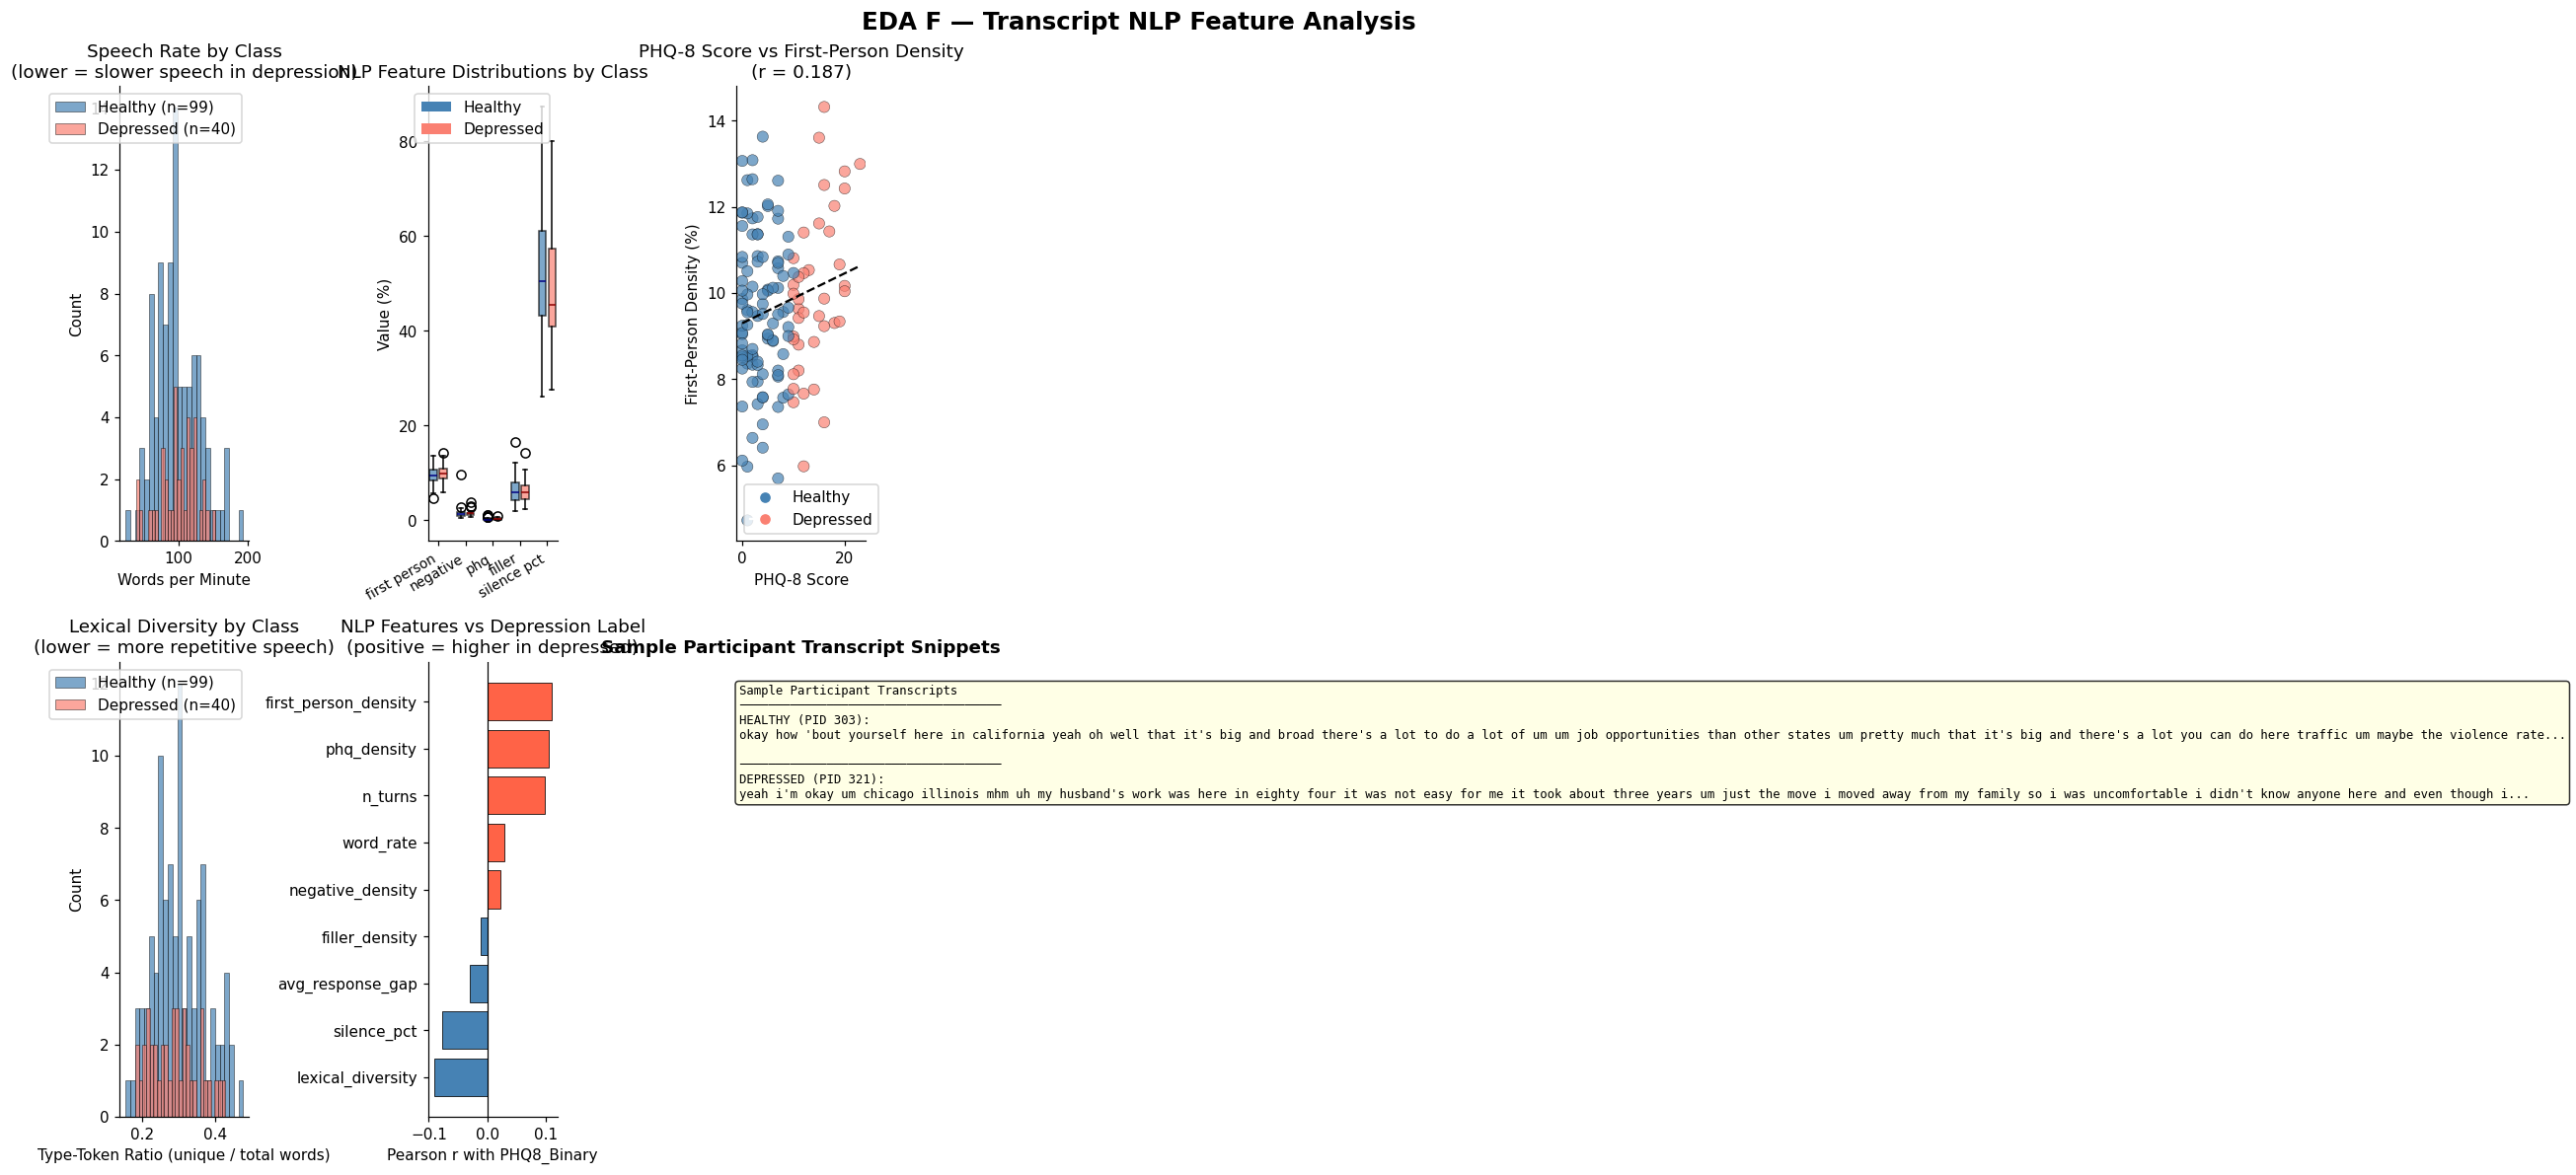


Top NLP correlations with depression:
lexical_diversity      -0.0914
silence_pct            -0.0768
avg_response_gap       -0.0296
filler_density         -0.0121
negative_density        0.0222
word_rate               0.0296
n_turns                 0.0985
phq_density             0.1051
first_person_density    0.1097

✓ EDA Section F complete — figure saved: eda_f_transcript_nlp.png
=== ALL EDA SECTIONS (A–F) COMPLETE — proceed to Section 3: Feature Extraction ===


In [13]:

# ── EDA F: Transcript NLP Feature Analysis ────────────────────────────────────
import re

FIRST_PERSON   = {'i', "i'm", "i've", "i'd", "i'll", 'myself', 'mine', 'me', 'my'}
NEGATIVE_WORDS = {'no','not','never','nothing','nobody','nowhere','neither','nor',
                  'cannot',"can't","won't","don't","didn't","doesn't",
                  'hate','awful','terrible','bad','horrible','worse','worst',
                  'sad','unhappy','hopeless','worthless','depressed','anxious','lonely'}
PHQ_KEYWORDS   = {'sleep','tired','fatigue','energy','appetite','weight','concentrate',
                  'concentration','hopeless','worthless','failure','guilty','suicide',
                  'pleasure','interest','enjoy'}
FILLER_WORDS   = {'um','uh','hmm','like','well','basically','actually','literally'}


def compute_nlp_features(pid):
    """Return dict of NLP features for one participant (PARTICIPANT turns only)."""
    fpath = os.path.join(DATA_DIR, f"{pid}_TRANSCRIPT.csv")
    if not os.path.exists(fpath):
        return None
    try:
        # Read with auto-header detection; strip whitespace from all string cols
        df = pd.read_csv(fpath, sep='\t')
        df.columns = df.columns.str.strip().str.lower()
        # Normalise speaker column
        df['speaker'] = df['speaker'].astype(str).str.strip().str.lower()
        df = df[df['speaker'] == 'participant'].dropna(subset=['value'])
        if df.empty:
            return None

        # Ensure numeric time columns
        df['start_time'] = pd.to_numeric(df['start_time'], errors='coerce')
        df['stop_time']  = pd.to_numeric(df['stop_time'],  errors='coerce')
        df = df.dropna(subset=['start_time','stop_time'])
        if df.empty:
            return None

        total_duration = df['stop_time'].max() - df['start_time'].min()
        if total_duration <= 0:
            return None

        text    = ' '.join(df['value'].astype(str).tolist()).lower()
        words   = re.findall(r"\b\w+\b", text)
        n_words = len(words)
        if n_words == 0:
            return None

        n_first  = sum(1 for w in words if w in FIRST_PERSON)
        n_neg    = sum(1 for w in words if w in NEGATIVE_WORDS)
        n_phq    = sum(1 for w in words if w in PHQ_KEYWORDS)
        n_fill   = sum(1 for w in words if w in FILLER_WORDS)
        n_unique = len(set(words))

        covered     = (df['stop_time'] - df['start_time']).clip(lower=0).sum()
        silence_pct = max(0.0, 1.0 - covered / total_duration)

        turns   = df.sort_values('start_time').reset_index(drop=True)
        gaps    = (turns['start_time'].iloc[1:].values - turns['stop_time'].iloc[:-1].values)
        avg_gap = float(np.mean(gaps)) if len(gaps) > 0 else 0.0

        return {
            'pid'                  : pid,
            'word_rate'            : n_words / (total_duration / 60.0),
            'silence_pct'          : silence_pct,
            'first_person_density' : n_first / n_words,
            'negative_density'     : n_neg   / n_words,
            'phq_density'          : n_phq   / n_words,
            'filler_density'       : n_fill  / n_words,
            'lexical_diversity'    : n_unique / n_words,
            'avg_response_gap'     : avg_gap,
            'n_turns'              : len(df),
        }
    except Exception:
        return None


# Use all_lbl (defined in EDA A) — has Participant_ID, PHQ8_Binary, PHQ8_Score
nlp_records = []
for _, row in all_lbl.iterrows():
    pid   = int(row['Participant_ID'])
    label = int(row['PHQ8_Binary'])
    score = row.get('PHQ8_Score', np.nan)
    rec   = compute_nlp_features(pid)
    if rec is not None:
        rec['label']     = label
        rec['phq_score'] = score
        nlp_records.append(rec)

nlp_df = pd.DataFrame(nlp_records)
print(f"NLP transcript records: {len(nlp_df)}")
print(nlp_df.groupby('label')[['word_rate','silence_pct','first_person_density',
                                'negative_density','phq_density','lexical_diversity']].mean().round(4).T.to_string())

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("EDA F — Transcript NLP Feature Analysis", fontsize=16, fontweight='bold')

CLR = {0: 'steelblue', 1: 'salmon'}
LBL = {0: 'Healthy', 1: 'Depressed'}

# F1 — Word rate histogram
ax = axes[0, 0]
for lb in [0, 1]:
    vals = nlp_df[nlp_df['label'] == lb]['word_rate'].dropna()
    ax.hist(vals, bins=25, alpha=0.7, color=CLR[lb], label=f"{LBL[lb]} (n={len(vals)})", edgecolor='k', linewidth=0.4)
ax.set_xlabel("Words per Minute")
ax.set_ylabel("Count")
ax.set_title("Speech Rate by Class\n(lower = slower speech in depression)")
ax.legend()

# F2 — NLP feature grouped boxplots
ax = axes[0, 1]
feat_box = ['first_person_density','negative_density','phq_density','filler_density','silence_pct']
feat_box = [f for f in feat_box if f in nlp_df.columns]
n_f = len(feat_box)
pos0 = np.arange(n_f) * 2.5
pos1 = pos0 + 0.9
ax.boxplot([nlp_df[nlp_df['label']==0][f].dropna().values * 100 for f in feat_box],
           positions=pos0, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7), medianprops=dict(color='navy'))
ax.boxplot([nlp_df[nlp_df['label']==1][f].dropna().values * 100 for f in feat_box],
           positions=pos1, widths=0.7, patch_artist=True,
           boxprops=dict(facecolor='salmon', alpha=0.7), medianprops=dict(color='darkred'))
ax.set_xticks(pos0 + 0.45)
ax.set_xticklabels([f.replace('_density','').replace('_',' ') for f in feat_box], rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Value (%)")
ax.set_title("NLP Feature Distributions by Class")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='steelblue', label='Healthy'), Patch(facecolor='salmon', label='Depressed')])

# F3 — First-person density vs PHQ-8
ax = axes[0, 2]
if 'phq_score' in nlp_df.columns and 'first_person_density' in nlp_df.columns:
    valid = nlp_df[['phq_score','first_person_density','label']].dropna()
    ax.scatter(valid['phq_score'], valid['first_person_density']*100,
               c=valid['label'].map(CLR), alpha=0.7, edgecolors='k', linewidths=0.3, s=55)
    if len(valid) > 2:
        z  = np.polyfit(valid['phq_score'], valid['first_person_density']*100, 1)
        xs = np.linspace(valid['phq_score'].min(), valid['phq_score'].max(), 100)
        ax.plot(xs, np.poly1d(z)(xs), 'k--', linewidth=1.5)
        r  = valid[['phq_score','first_person_density']].corr().iloc[0,1]
        ax.set_title(f"PHQ-8 Score vs First-Person Density\n(r = {r:.3f})")
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='Healthy'),
                       Line2D([0],[0],marker='o',color='w',markerfacecolor='salmon',ms=8,label='Depressed')])
    ax.set_xlabel("PHQ-8 Score")
    ax.set_ylabel("First-Person Density (%)")

# F4 — Lexical diversity
ax = axes[1, 0]
for lb in [0, 1]:
    vals = nlp_df[nlp_df['label'] == lb]['lexical_diversity'].dropna()
    ax.hist(vals, bins=25, alpha=0.7, color=CLR[lb], label=f"{LBL[lb]} (n={len(vals)})", edgecolor='k', linewidth=0.4)
ax.set_xlabel("Type-Token Ratio (unique / total words)")
ax.set_ylabel("Count")
ax.set_title("Lexical Diversity by Class\n(lower = more repetitive speech)")
ax.legend()

# F5 — NLP feature correlations
ax = axes[1, 1]
nlp_feat_cols = ['word_rate','silence_pct','first_person_density','negative_density',
                 'phq_density','filler_density','lexical_diversity','avg_response_gap','n_turns']
nlp_feat_cols = [f for f in nlp_feat_cols if f in nlp_df.columns]
corr_nlp  = nlp_df[nlp_feat_cols + ['label']].corr()['label'].drop('label').sort_values()
clrs_bar  = ['tomato' if v >= 0 else 'steelblue' for v in corr_nlp.values]
ax.barh(corr_nlp.index, corr_nlp.values, color=clrs_bar, edgecolor='k', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Pearson r with PHQ8_Binary")
ax.set_title("NLP Features vs Depression Label\n(positive = higher in depressed)")

# F6 — Sample transcript snippets
ax = axes[1, 2]
ax.axis('off')

def get_snippet(pid, max_words=50):
    if pid is None: return "N/A"
    fpath = os.path.join(DATA_DIR, f"{pid}_TRANSCRIPT.csv")
    if not os.path.exists(fpath): return "N/A"
    try:
        df = pd.read_csv(fpath, sep='\t')
        df.columns = df.columns.str.strip().str.lower()
        df['speaker'] = df['speaker'].astype(str).str.strip().str.lower()
        df = df[df['speaker'] == 'participant'].dropna(subset=['value'])
        if df.empty: return "N/A"
        words = ' '.join(df['value'].astype(str)).split()[:max_words]
        return ' '.join(words) + ('...' if len(words) == max_words else '')
    except Exception:
        return "N/A"

dep_pid = nlp_df[nlp_df['label']==1]['pid'].iloc[0] if len(nlp_df[nlp_df['label']==1]) > 0 else None
hlt_pid = nlp_df[nlp_df['label']==0]['pid'].iloc[0] if len(nlp_df[nlp_df['label']==0]) > 0 else None

snip_dep = get_snippet(dep_pid)
snip_hlt = get_snippet(hlt_pid)
txt = f"Sample Participant Transcripts\n{'─'*36}\n"
txt += f"HEALTHY (PID {hlt_pid}):\n{snip_hlt}\n\n"
txt += f"{'─'*36}\n"
txt += f"DEPRESSED (PID {dep_pid}):\n{snip_dep}"
ax.text(0.02, 0.95, txt, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title("Sample Participant Transcript Snippets", fontweight='bold')

plt.tight_layout()
plt.savefig("eda_f_transcript_nlp.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop NLP correlations with depression:")
print(corr_nlp.to_string())
print("\n✓ EDA Section F complete — figure saved: eda_f_transcript_nlp.png")
print("=== ALL EDA SECTIONS (A–F) COMPLETE — proceed to Section 3: Feature Extraction ===")


## Section 3 — Feature Extraction Functions (per Modality)

Each function takes a `participant_id` and returns a flat dict of `{feature_name: value}`.  
All temporal signals are summarised with **mean, std, min, max** — giving a fixed-length vector regardless of session length.  
Confidence filtering is applied to CLNF-based modalities.

In [14]:
def _aggregate(arr: np.ndarray, prefix: str) -> dict:
    """
    Compute mean, std, min, max of a 1-D array and return as a prefixed dict.
    Skips NaN-only arrays gracefully.
    """
    if arr is None or len(arr) == 0:
        return {f"{prefix}_{s}": np.nan for s in STAT_FUNCS}
    return {f"{prefix}_{stat}": fn(arr) for stat, fn in STAT_FUNCS.items()}


# ──────────────────────────────────────────────────────────────────────────────
# 3-A  COVAREP  (74 acoustic / prosodic features, ~100 Hz frame rate)
# ──────────────────────────────────────────────────────────────────────────────
def extract_covarep(pid: int) -> dict:
    """
    Loads {pid}_COVAREP.csv (74 columns, no header, one frame per row).

    Special handling:
    - Column 0  = F0 (Hz).  0 means unvoiced; we keep ALL frames for statistics
      BUT also compute voiced-only F0 stats (F0 > 0) as extra features capturing
      pitch range, which is a known depression biomarker.
    - Column 1  = VUV (1=voiced, 0=unvoiced).  Compute voiced frame ratio.
    - Columns 2–73 = other acoustic params — aggregate with mean/std/min/max.

    Returns: flat dict with keys like  F0_mean, F0_std, ..., HMPDD_13_max
             plus  voiced_ratio, f0_voiced_mean, f0_voiced_std, f0_voiced_range
    """
    path = os.path.join(DATA_DIR, f"{pid}_COVAREP.csv")
    feat = {}

    if not os.path.exists(path):
        # Return NaN dict with expected key names
        for col in COVAREP_COLS:
            feat.update(_aggregate(None, f"covarep_{col}"))
        feat.update({
            "covarep_voiced_ratio":   np.nan,
            "covarep_f0_voiced_mean": np.nan,
            "covarep_f0_voiced_std":  np.nan,
            "covarep_f0_voiced_range": np.nan,
        })
        return feat

    df = pd.read_csv(path, header=None)
    df.columns = COVAREP_COLS[:df.shape[1]]   # align column names safely

    # Standard aggregation: all frames, all 74 columns
    for col in df.columns:
        feat.update(_aggregate(df[col].values, f"covarep_{col}"))

    # Voiced-frame-only F0 statistics
    if "F0" in df.columns and "VUV" in df.columns:
        voiced_frames = df[df["VUV"] > 0]
        voiced_f0     = voiced_frames["F0"].values
        total_frames  = len(df)
        voiced_ratio  = len(voiced_frames) / total_frames if total_frames > 0 else 0.0

        feat["covarep_voiced_ratio"]    = voiced_ratio
        feat["covarep_f0_voiced_mean"]  = float(np.nanmean(voiced_f0)) if len(voiced_f0) > 0 else 0.0
        feat["covarep_f0_voiced_std"]   = float(np.nanstd(voiced_f0))  if len(voiced_f0) > 0 else 0.0
        feat["covarep_f0_voiced_range"] = (float(np.nanmax(voiced_f0) - np.nanmin(voiced_f0))
                                            if len(voiced_f0) > 1 else 0.0)
    return feat


# ──────────────────────────────────────────────────────────────────────────────
# 3-B  FORMANT  (F1–F5 Hz, one frame per row, same rate as COVAREP)
# ──────────────────────────────────────────────────────────────────────────────
def extract_formant(pid: int) -> dict:
    """
    Loads {pid}_FORMANT.csv (5 columns: F1 F2 F3 F4 F5).
    Aggregates each formant with mean, std, min, max → 20 features.
    Also adds F2-F1 dispersion (vocal tract length proxy) → 3 more features.
    """
    path = os.path.join(DATA_DIR, f"{pid}_FORMANT.csv")
    feat = {}

    if not os.path.exists(path):
        for col in FORMANT_COLS:
            feat.update(_aggregate(None, f"formant_{col}"))
        feat.update({"formant_F2F1_mean": np.nan, "formant_F2F1_std": np.nan,
                     "formant_F3F1_mean": np.nan})
        return feat

    df = pd.read_csv(path, header=None, names=FORMANT_COLS)

    # Replace implausible formant values (0 or negative) with NaN
    df = df.replace(0, np.nan)
    df[df < 0] = np.nan

    for col in FORMANT_COLS:
        feat.update(_aggregate(df[col].values, f"formant_{col}"))

    # Formant dispersion ratios
    feat["formant_F2F1_mean"] = float(np.nanmean(df["F2"] - df["F1"]))
    feat["formant_F2F1_std"]  = float(np.nanstd(df["F2"]  - df["F1"]))
    feat["formant_F3F1_mean"] = float(np.nanmean(df["F3"] - df["F1"]))
    return feat


# ──────────────────────────────────────────────────────────────────────────────
# 3-C  CLNF_AUs  (Facial Action Units — OpenFace output)
# ──────────────────────────────────────────────────────────────────────────────
AU_R_COLS = ["AU01_r","AU02_r","AU04_r","AU05_r","AU06_r","AU09_r","AU10_r",
             "AU12_r","AU14_r","AU15_r","AU17_r","AU20_r","AU25_r","AU26_r"]
AU_C_COLS = ["AU04_c","AU12_c","AU15_c","AU23_c","AU28_c","AU45_c"]

def extract_clnf_aus(pid: int, conf_thresh: float = 0.5) -> dict:
    """
    Loads {pid}_CLNF_AUs.txt.
    Filters rows where confidence >= conf_thresh AND success == 1.
    AU_r (intensity, continuous): aggregate with mean + std  → 14×2 = 28 features
    AU_c (binary presence):       aggregate with mean (= occurrence rate) → 6 features
    Also adds: avg_confidence, pct_successful_frames.
    """
    path = os.path.join(DATA_DIR, f"{pid}_CLNF_AUs.txt")
    feat = {}

    if not os.path.exists(path):
        for col in AU_R_COLS:
            feat[f"au_{col}_mean"] = np.nan
            feat[f"au_{col}_std"]  = np.nan
        for col in AU_C_COLS:
            feat[f"au_{col}_rate"] = np.nan
        feat.update({"au_avg_confidence": np.nan, "au_pct_success": np.nan})
        return feat

    df         = pd.read_csv(path)
    df.columns = df.columns.str.strip()    # remove leading spaces from header

    total_frames = len(df)
    df_conf      = df[(df["confidence"] >= conf_thresh) & (df["success"] == 1)]
    pct_success  = len(df_conf) / total_frames if total_frames > 0 else 0.0
    avg_conf     = df_conf["confidence"].mean() if len(df_conf) > 0 else 0.0

    feat["au_avg_confidence"] = float(avg_conf)
    feat["au_pct_success"]    = float(pct_success)

    for col in AU_R_COLS:
        vals = df_conf[col].values if col in df_conf.columns else np.array([])
        feat[f"au_{col}_mean"] = float(np.nanmean(vals)) if len(vals) > 0 else np.nan
        feat[f"au_{col}_std"]  = float(np.nanstd(vals))  if len(vals) > 0 else np.nan

    for col in AU_C_COLS:
        vals = df_conf[col].values if col in df_conf.columns else np.array([])
        feat[f"au_{col}_rate"] = float(np.nanmean(vals)) if len(vals) > 0 else np.nan

    return feat


# ──────────────────────────────────────────────────────────────────────────────
# 3-D  CLNF_pose  (Head pose: translation Tx,Ty,Tz + rotation Rx,Ry,Rz)
# ──────────────────────────────────────────────────────────────────────────────
POSE_COLS = ["Tx","Ty","Tz","Rx","Ry","Rz"]

def extract_clnf_pose(pid: int, conf_thresh: float = 0.5) -> dict:
    """
    Loads {pid}_CLNF_pose.txt.  Confidence-filters and aggregates 6 pose dims.
    Also computes head movement energy = sqrt(mean of squared angular derivatives).
    → 6×4 + 2 = 26 features
    """
    path = os.path.join(DATA_DIR, f"{pid}_CLNF_pose.txt")
    feat = {}

    if not os.path.exists(path):
        for col in POSE_COLS:
            feat.update(_aggregate(None, f"pose_{col}"))
        feat.update({"pose_rot_energy": np.nan, "pose_trans_energy": np.nan})
        return feat

    df         = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df_conf    = df[(df["confidence"] >= conf_thresh) & (df["success"] == 1)]

    for col in POSE_COLS:
        vals = df_conf[col].values if col in df_conf.columns else np.array([])
        feat.update(_aggregate(vals, f"pose_{col}"))

    # Head movement energy (captures psychomotor retardation in depression)
    if all(c in df_conf.columns for c in ["Rx","Ry","Rz"]):
        rot = df_conf[["Rx","Ry","Rz"]].values
        rot_diff        = np.diff(rot, axis=0)
        feat["pose_rot_energy"]   = float(np.sqrt(np.mean(rot_diff**2))) if len(rot_diff) > 0 else 0.0
    else:
        feat["pose_rot_energy"] = np.nan

    if all(c in df_conf.columns for c in ["Tx","Ty","Tz"]):
        trans = df_conf[["Tx","Ty","Tz"]].values
        trans_diff = np.diff(trans, axis=0)
        feat["pose_trans_energy"] = float(np.sqrt(np.mean(trans_diff**2))) if len(trans_diff) > 0 else 0.0
    else:
        feat["pose_trans_energy"] = np.nan

    return feat


# ──────────────────────────────────────────────────────────────────────────────
# 3-E  CLNF_gaze  (Eye gaze vectors — left eye, right eye, head orientations)
# ──────────────────────────────────────────────────────────────────────────────
GAZE_COLS = ["x_0","y_0","z_0","x_1","y_1","z_1",
             "x_h0","y_h0","z_h0","x_h1","y_h1","z_h1"]

def extract_clnf_gaze(pid: int, conf_thresh: float = 0.5) -> dict:
    """
    Loads {pid}_CLNF_gaze.txt.  12 gaze components × 4 stats = 48 features.
    Also adds: gaze_variability = std of horizontal gaze direction (gaze avoidance proxy).
    """
    path = os.path.join(DATA_DIR, f"{pid}_CLNF_gaze.txt")
    feat = {}

    if not os.path.exists(path):
        for col in GAZE_COLS:
            feat.update(_aggregate(None, f"gaze_{col}"))
        feat["gaze_variability"] = np.nan
        return feat

    df         = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df_conf    = df[(df["confidence"] >= conf_thresh) & (df["success"] == 1)]

    for col in GAZE_COLS:
        vals = df_conf[col].values if col in df_conf.columns else np.array([])
        feat.update(_aggregate(vals, f"gaze_{col}"))

    # Gaze variability: std of mean gaze x across both eyes (avoidance / aversion)
    if "x_0" in df_conf.columns and "x_1" in df_conf.columns:
        mean_gaze_x       = (df_conf["x_0"].values + df_conf["x_1"].values) / 2.0
        feat["gaze_variability"] = float(np.nanstd(mean_gaze_x))
    else:
        feat["gaze_variability"] = np.nan

    return feat

print("✓ COVAREP, FORMANT, CLNF_AUs, CLNF_pose, CLNF_gaze extractors defined")

✓ COVAREP, FORMANT, CLNF_AUs, CLNF_pose, CLNF_gaze extractors defined


In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# 3-F  TRANSCRIPT  (NLP / paralinguistic features from participant turns)
# ──────────────────────────────────────────────────────────────────────────────

# First-person pronouns (depression marker: elevated self-focus)
FIRST_PERSON = {"i","me","my","myself","mine","i'm","i've","i'd","i'll"}

# Negative-affect words (curated from LIWC/PHQ vocabulary)
NEGATIVE_WORDS = {
    "sad","depress","depressed","hopeless","worthless","helpless","empty",
    "tired","exhausted","lonely","alone","miserable","fail","failure","guilt",
    "guilty","shame","ashamed","dead","die","dying","suicide","hurt","pain",
    "anxious","anxiety","worry","worried","fear","scared","terrible","awful",
    "bad","worst","hate","angry","angry","irritable","numb","lost","dark",
    "nothing","never","no","not","cant","cannot","wont","dont","shouldnt"
}

# PHQ-9 related symptom keywords
PHQ_KEYWORDS = {
    "sleep","insomnia","awake","nap","rest","tired","energy","concentrate",
    "focus","appetite","eat","food","weight","interest","enjoy","pleasure",
    "slow","fast","moving","restless","thoughts","think","thinking","dead",
    "hurt","better","off","depressed","hopeless","failure","guilty"
}

# Filler / disfluency words (speech rate disruption in depression)
FILLER_WORDS = {"um","uh","hmm","hm","uhh","umm","like","you know","i mean"}

def extract_transcript(pid: int) -> dict:
    """
    Loads {pid}_TRANSCRIPT.csv (tab-separated: start_time, stop_time, speaker, value).
    Analyses ONLY the Participant (patient) turns — excludes Ellie's turns.

    Features extracted:
      num_responses          — how many times the participant spoke
      total_words            — total word count across all responses
      avg_words_per_response — mean response length in words
      word_rate_per_min      — words per minute (total / total speaking time × 60)
      total_speaking_duration_s — sum of all participant turn durations (seconds)
      pct_silence            — proportion of session that is silence/Ellie's speech
      first_person_density   — first-person pronouns / total words
      negative_word_density  — negative-affect words / total words
      phq_keyword_density    — PHQ-9 related words / total words
      filler_density         — filler words / total words
      avg_response_gap_s     — mean gap between consecutive participant responses
      std_response_gap_s     — std of those gaps (variability in latency)
      lexical_diversity      — unique words / total words (type-token ratio)
      avg_response_duration_s — mean duration of a single participant turn (seconds)
    """
    path = os.path.join(DATA_DIR, f"{pid}_TRANSCRIPT.csv")
    default = {k: np.nan for k in [
        "nlp_num_responses","nlp_total_words","nlp_avg_words_per_response",
        "nlp_word_rate_per_min","nlp_total_speaking_duration_s","nlp_pct_silence",
        "nlp_first_person_density","nlp_negative_word_density",
        "nlp_phq_keyword_density","nlp_filler_density",
        "nlp_avg_response_gap_s","nlp_std_response_gap_s",
        "nlp_lexical_diversity","nlp_avg_response_duration_s"
    ]}

    if not os.path.exists(path):
        return default

    df = pd.read_csv(path, sep="\t")
    df.columns = df.columns.str.strip().str.lower()

    # Filter participant-only rows
    ptcp = df[df["speaker"].str.strip().str.lower() == "participant"].copy()

    if len(ptcp) == 0:
        return default

    ptcp = ptcp.dropna(subset=["value"])
    ptcp["value"] = ptcp["value"].astype(str)

    # Tokenise
    all_tokens   = []
    response_wcs = []
    for text in ptcp["value"]:
        tokens = re.findall(r"\b[a-z']+\b", text.lower())
        all_tokens.extend(tokens)
        response_wcs.append(len(tokens))

    total_words = len(all_tokens)
    num_resp    = len(ptcp)

    # Speaking durations
    durations = (ptcp["stop_time"].values - ptcp["start_time"].values).astype(float)
    total_speaking = float(np.nansum(durations))

    # Session span (first word to last)
    session_span = float(ptcp["stop_time"].max() - ptcp["start_time"].min())

    # Response gaps (time between consecutive participant turns)
    starts = ptcp["start_time"].values.astype(float)
    stops  = ptcp["stop_time"].values.astype(float)
    if num_resp > 1:
        gaps = starts[1:] - stops[:-1]
        gaps = gaps[gaps >= 0]   # remove negative artefacts
        avg_gap = float(np.nanmean(gaps)) if len(gaps) > 0 else 0.0
        std_gap = float(np.nanstd(gaps))  if len(gaps) > 0 else 0.0
    else:
        avg_gap, std_gap = 0.0, 0.0

    # Lexical features
    if total_words == 0:
        return default

    fp_count  = sum(1 for t in all_tokens if t in FIRST_PERSON)
    neg_count = sum(1 for t in all_tokens if t in NEGATIVE_WORDS)
    phq_count = sum(1 for t in all_tokens if t in PHQ_KEYWORDS)
    fill_cnt  = sum(1 for t in all_tokens if t in FILLER_WORDS)
    unique_w  = len(set(all_tokens))

    feat = {
        "nlp_num_responses"             : int(num_resp),
        "nlp_total_words"               : int(total_words),
        "nlp_avg_words_per_response"    : float(np.mean(response_wcs)),
        "nlp_word_rate_per_min"         : float(total_words / total_speaking * 60)
                                            if total_speaking > 0 else 0.0,
        "nlp_total_speaking_duration_s" : total_speaking,
        "nlp_pct_silence"               : float(1.0 - total_speaking / session_span)
                                            if session_span > 0 else 0.0,
        "nlp_first_person_density"      : float(fp_count  / total_words),
        "nlp_negative_word_density"     : float(neg_count / total_words),
        "nlp_phq_keyword_density"       : float(phq_count / total_words),
        "nlp_filler_density"            : float(fill_cnt  / total_words),
        "nlp_avg_response_gap_s"        : avg_gap,
        "nlp_std_response_gap_s"        : std_gap,
        "nlp_lexical_diversity"         : float(unique_w / total_words),
        "nlp_avg_response_duration_s"   : float(np.mean(durations)),
    }
    return feat

print("✓ Transcript NLP extractor defined")

✓ Transcript NLP extractor defined


## Section 4 — Load Labels and Run Extraction for All Participants

In [16]:
LABEL_COLS = [
    "Participant_ID", "PHQ8_Binary", "PHQ8_Score", "Gender",
    "PHQ8_NoInterest", "PHQ8_Depressed", "PHQ8_Sleep", "PHQ8_Tired",
    "PHQ8_Appetite", "PHQ8_Failure", "PHQ8_Concentrating", "PHQ8_Moving",
]

df_train = pd.read_csv(TRAIN_CSV)[LABEL_COLS].assign(split="train")
df_dev = pd.read_csv(DEV_CSV)[LABEL_COLS].assign(split="val")

df_test_meta = pd.read_csv(TEST_CSV)
df_test_meta.columns = [c.strip() for c in df_test_meta.columns]
df_test_meta = df_test_meta.rename(columns={"participant_ID": "Participant_ID"})

# Use approved full test labels when available.
if os.path.exists(FULL_TEST_CSV):
    df_full = pd.read_csv(FULL_TEST_CSV)
    df_full.columns = [c.strip() for c in df_full.columns]
    df_full = df_full.rename(columns={
        "participant_ID": "Participant_ID",
        "PHQ_Binary": "PHQ8_Binary",
        "PHQ_Score": "PHQ8_Score",
    })

    keep = [c for c in ["Participant_ID", "PHQ8_Binary", "PHQ8_Score", "Gender"] if c in df_full.columns]
    df_full = df_full[keep].copy()

    df_test = df_test_meta.merge(df_full, on="Participant_ID", how="left", suffixes=("", "_full"))
    if "Gender_full" in df_test.columns:
        df_test["Gender"] = df_test["Gender"].fillna(df_test["Gender_full"])
        df_test = df_test.drop(columns=["Gender_full"])
else:
    df_test = df_test_meta.copy()

# Ensure schema consistency: if a column is unavailable in test, keep it as NaN.
for col in LABEL_COLS[1:]:
    if col not in df_test.columns:
        df_test[col] = np.nan

df_test = df_test[["Participant_ID"] + LABEL_COLS[1:]].assign(split="test")

labels_df = pd.concat([df_train, df_dev, df_test], ignore_index=True)
labels_df["Participant_ID"] = labels_df["Participant_ID"].astype(int)

print(f"Total participants: {len(labels_df)}")
print(labels_df.groupby("split")[["Participant_ID", "PHQ8_Binary"]].agg(
    {"Participant_ID": "count", "PHQ8_Binary": "sum"}
).rename(columns={"Participant_ID": "n_sessions", "PHQ8_Binary": "n_depressed"}))
print("\nLabel distributions:")
print(labels_df.groupby(["split", "PHQ8_Binary"])["Participant_ID"].count().unstack(fill_value=0))

test_labeled = int(labels_df.loc[labels_df["split"] == "test", "PHQ8_Binary"].notna().sum())
print(f"\nTest labels available: {test_labeled}/{(labels_df['split'] == 'test').sum()}")

Total participants: 189
       n_sessions  n_depressed
split                         
test           47           14
train         107           30
val            35           12

Label distributions:
PHQ8_Binary   0   1
split              
test         33  14
train        77  30
val          23  12

Test labels available: 47/47


In [19]:
def extract_all(pid: int) -> dict:
    """
    Run all 6 modality extractors for a single participant and merge into one dict.
    """
    feat = {"Participant_ID": pid}
    feat.update(extract_covarep(pid))
    feat.update(extract_formant(pid))
    feat.update(extract_clnf_aus(pid))
    feat.update(extract_clnf_pose(pid))
    feat.update(extract_clnf_gaze(pid))
    feat.update(extract_transcript(pid))
    return feat

# ── Run extraction for every participant in the dataset ────────────────────────
all_pids = labels_df["Participant_ID"].tolist()
print(f"Extracting features for {len(all_pids)} participants …")

records = []
for pid in tqdm(all_pids, desc="Participants"):
    records.append(extract_all(pid))

features_df = pd.DataFrame(records)
features_df["Participant_ID"] = features_df["Participant_ID"].astype(int)

print(f"\n✓ Raw feature matrix shape: {features_df.shape}")
print(f"  Rows = participants, Columns = features + Participant_ID")

Extracting features for 189 participants …


Participants:   0%|          | 0/189 [00:00<?, ?it/s]


✓ Raw feature matrix shape: (189, 449)
  Rows = participants, Columns = features + Participant_ID


In [18]:

# ── Robustness patches — run this cell ONCE after the extraction cells ────────
# Completely replaces _aggregate (no closure chaining → no recursion risk)

def _aggregate(arr, prefix: str) -> dict:
    """Compute STAT_FUNCS stats on arr; coerces to float to handle object arrays."""
    if arr is None or len(arr) == 0:
        return {f"{prefix}_{s}": np.nan for s in STAT_FUNCS}
    # Force numeric — silently converts strings / object values to NaN
    arr = pd.to_numeric(pd.Series(arr), errors='coerce').values
    return {f"{prefix}_{stat}": fn(arr) for stat, fn in STAT_FUNCS.items()}


def extract_clnf_pose(pid: int, conf_thresh: float = 0.5) -> dict:
    path = os.path.join(DATA_DIR, f"{pid}_CLNF_pose.txt")
    feat = {}

    if not os.path.exists(path):
        for col in POSE_COLS:
            feat.update(_aggregate(None, f"pose_{col}"))
        feat.update({"pose_rot_energy": np.nan, "pose_trans_energy": np.nan})
        return feat

    df         = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    # Force all non-frame/success columns to float
    for c in df.columns:
        if c not in ('frame', 'success'):
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df_conf = df[(df["confidence"] >= conf_thresh) & (df["success"] == 1)].copy()

    for col in POSE_COLS:
        vals = df_conf[col].values if col in df_conf.columns else np.array([])
        feat.update(_aggregate(vals, f"pose_{col}"))

    if all(c in df_conf.columns for c in ["Rx", "Ry", "Rz"]):
        rot      = df_conf[["Rx","Ry","Rz"]].values.astype(float)
        rot_diff = np.diff(rot, axis=0)
        feat["pose_rot_energy"] = float(np.sqrt(np.mean(rot_diff**2))) if len(rot_diff) > 0 else 0.0
    else:
        feat["pose_rot_energy"] = np.nan

    if all(c in df_conf.columns for c in ["Tx", "Ty", "Tz"]):
        trans      = df_conf[["Tx","Ty","Tz"]].values.astype(float)
        trans_diff = np.diff(trans, axis=0)
        feat["pose_trans_energy"] = float(np.sqrt(np.mean(trans_diff**2))) if len(trans_diff) > 0 else 0.0
    else:
        feat["pose_trans_energy"] = np.nan

    return feat


def extract_clnf_gaze(pid: int, conf_thresh: float = 0.5) -> dict:
    path = os.path.join(DATA_DIR, f"{pid}_CLNF_gaze.txt")
    feat = {}

    if not os.path.exists(path):
        for col in GAZE_COLS:
            feat.update(_aggregate(None, f"gaze_{col}"))
        feat["gaze_variability"] = np.nan
        return feat

    df         = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    for c in df.columns:
        if c not in ('frame', 'success'):
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df_conf = df[(df["confidence"] >= conf_thresh) & (df["success"] == 1)].copy()

    for col in GAZE_COLS:
        vals = df_conf[col].values if col in df_conf.columns else np.array([])
        feat.update(_aggregate(vals, f"gaze_{col}"))

    if "x_0" in df_conf.columns and "x_1" in df_conf.columns:
        mean_gaze_x      = (df_conf["x_0"].values.astype(float) + df_conf["x_1"].values.astype(float)) / 2.0
        feat["gaze_variability"] = float(np.nanstd(mean_gaze_x))
    else:
        feat["gaze_variability"] = np.nan

    return feat


print("✓ _aggregate, extract_clnf_pose, extract_clnf_gaze — patched (no recursion)")


✓ _aggregate, extract_clnf_pose, extract_clnf_gaze — patched (no recursion)


## Section 5 — Merge Features + Labels, Inspect Missing Values

In [20]:
# ── Merge features with labels and split assignment ────────────────────────────
merged = labels_df.merge(features_df, on="Participant_ID", how="left")

print(f"Merged shape: {merged.shape}")
print(f"Columns: {list(merged.columns[:20])} ...")

# ── Missing value report ───────────────────────────────────────────────────────
feat_cols = [c for c in merged.columns
             if c not in ["Participant_ID","PHQ8_Binary","PHQ8_Score","Gender",
                          "PHQ8_NoInterest","PHQ8_Depressed","PHQ8_Sleep","PHQ8_Tired",
                          "PHQ8_Appetite","PHQ8_Failure","PHQ8_Concentrating","PHQ8_Moving","split"]]

nan_summary = merged[feat_cols].isna().sum()
nan_pct     = (nan_summary / len(merged) * 100).round(1)
miss_report = pd.DataFrame({"n_missing": nan_summary, "pct_missing": nan_pct})
miss_report = miss_report[miss_report["n_missing"] > 0].sort_values("pct_missing", ascending=False)

print(f"\n✓ Feature columns with ANY missing values: {len(miss_report)}")
if len(miss_report) > 0:
    print(miss_report.head(20))
else:
    print("  No missing values — all participants have all modalities present.")

# ── Drop columns with > 50 % missing (whole modality missing for most subjects) –
HIGH_MISS_THRESH = 50.0
cols_to_drop = nan_pct[nan_pct > HIGH_MISS_THRESH].index.tolist()
if cols_to_drop:
    print(f"\n⚠ Dropping {len(cols_to_drop)} columns with >{HIGH_MISS_THRESH}% missing:")
    print(cols_to_drop[:10], "...")
    merged.drop(columns=cols_to_drop, inplace=True)
    feat_cols = [c for c in feat_cols if c not in cols_to_drop]
else:
    print(f"\n✓ No columns exceed {HIGH_MISS_THRESH}% missing — keeping all feature columns.")

# ── Impute remaining NaNs with per-split training mean (no leakage) ─────────
#    We compute col means only on train split and fill everywhere
train_rows = merged["split"] == "train"
col_means  = merged.loc[train_rows, feat_cols].mean()
merged[feat_cols] = merged[feat_cols].fillna(col_means)

remaining_nan = merged[feat_cols].isna().sum().sum()
print(f"\nNaN values remaining after imputation: {remaining_nan}")

Merged shape: (189, 461)
Columns: ['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving', 'split', 'covarep_F0_mean', 'covarep_F0_std', 'covarep_F0_min', 'covarep_F0_max', 'covarep_VUV_mean', 'covarep_VUV_std', 'covarep_VUV_min'] ...

✓ Feature columns with ANY missing values: 448
                       n_missing  pct_missing
covarep_peakSlope_std         17       9.0000
gaze_y_h0_max                  4       2.1000
gaze_z_h0_mean                 4       2.1000
gaze_z_h0_std                  4       2.1000
gaze_z_h0_min                  4       2.1000
gaze_z_h0_max                  4       2.1000
gaze_x_h1_mean                 4       2.1000
gaze_x_h1_std                  4       2.1000
gaze_x_h1_min                  4       2.1000
gaze_x_h1_max                  4       2.1000
gaze_y_h1_mean                 4       2.1000
gaze_y_h1_std                

## Section 6 — Normalize and Scale Features (Fit on Train Only)

In [21]:

# ── Fit StandardScaler ONLY on training rows ──────────────────────────────────
scaler    = StandardScaler()
train_idx = merged["split"] == "train"
val_idx   = merged["split"] == "val"
test_idx  = merged["split"] == "test"

X_train_raw = merged.loc[train_idx, feat_cols].values.astype(np.float64)
X_val_raw   = merged.loc[val_idx,   feat_cols].values.astype(np.float64)
X_test_raw  = merged.loc[test_idx,  feat_cols].values.astype(np.float64)

# Replace ±inf with NaN then impute with per-column TRAIN median
for X in (X_train_raw, X_val_raw, X_test_raw):
    X[~np.isfinite(X)] = np.nan

train_medians = np.nanmedian(X_train_raw, axis=0)
for X in (X_train_raw, X_val_raw, X_test_raw):
    nan_mask = np.isnan(X)
    X[nan_mask] = np.take(train_medians, np.where(nan_mask)[1])

n_inf = int(np.sum(~np.isfinite(X_train_raw)))
print(f"Residual non-finite values after imputation: {n_inf}")

scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw).astype(np.float32)
X_val   = scaler.transform(X_val_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\n✓ Scaler fitted on train only — no data leakage")


Residual non-finite values after imputation: 0
X_train : (107, 448)
X_val   : (35, 448)
X_test  : (47, 448)

✓ Scaler fitted on train only — no data leakage


## Section 7 — Encode Labels and Inspect Class Distribution


train split class distribution:
  Not Depressed (label=0): 77/107 = 72.0%
  Depressed (label=1): 30/107 = 28.0%

val split class distribution:
  Not Depressed (label=0): 23/35 = 65.7%
  Depressed (label=1): 12/35 = 34.3%


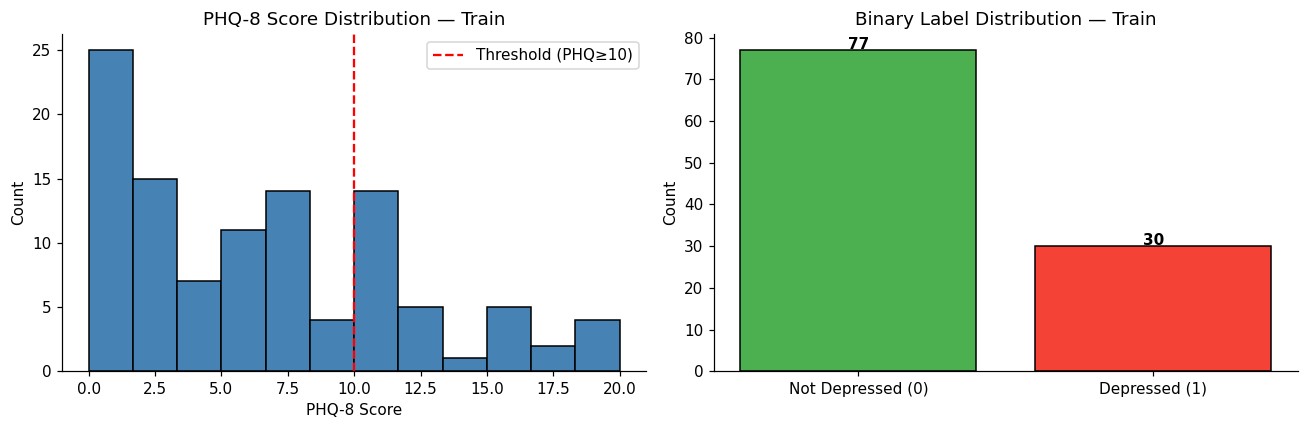


✓ Labels extracted: y_train_bin=(107,), y_val_bin=(35,)


In [22]:
# ── Extract label vectors for each split ──────────────────────────────────────
# y_binary : 0 = not depressed, 1 = depressed  (classification target)
# y_score  : PHQ-8 continuous score 0–24        (regression target)
y_train_bin   = merged.loc[train_idx, "PHQ8_Binary"].values.astype(np.int32)
y_val_bin     = merged.loc[val_idx,   "PHQ8_Binary"].values.astype(np.int32)
y_test_bin    = merged.loc[test_idx,  "PHQ8_Binary"].values       # may be NaN

y_train_score = merged.loc[train_idx, "PHQ8_Score"].values.astype(np.float32)
y_val_score   = merged.loc[val_idx,   "PHQ8_Score"].values.astype(np.float32)
y_test_score  = merged.loc[test_idx,  "PHQ8_Score"].values        # may be NaN

# ── Class balance report ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

for split_name, y_bin in [("train", y_train_bin), ("val", y_val_bin)]:
    unique, counts = np.unique(y_bin, return_counts=True)
    total          = counts.sum()
    print(f"\n{split_name} split class distribution:")
    for u, c in zip(unique, counts):
        label = "Depressed" if u == 1 else "Not Depressed"
        print(f"  {label} (label={u}): {c}/{total} = {100*c/total:.1f}%")

# ── PHQ-8 score distribution (train) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train_score, bins=12, edgecolor="black", color="steelblue")
axes[0].axvline(10, color="red", linestyle="--", label="Threshold (PHQ≥10)")
axes[0].set_xlabel("PHQ-8 Score"); axes[0].set_ylabel("Count")
axes[0].set_title("PHQ-8 Score Distribution — Train")
axes[0].legend()

train_bin_counts = pd.Series(y_train_bin).value_counts().sort_index()
axes[1].bar(["Not Depressed (0)", "Depressed (1)"],
            train_bin_counts.values, color=["#4CAF50","#F44336"],
            edgecolor="black")
axes[1].set_title("Binary Label Distribution — Train")
axes[1].set_ylabel("Count")
for i, v in enumerate(train_bin_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\n✓ Labels extracted: y_train_bin={y_train_bin.shape}, y_val_bin={y_val_bin.shape}")

## Section 8 — Final Feature Matrix Inspection

  DAIC-WOZ — Final Feature Matrix Summary
  Modality              # Features
----------------------------------------------------
  COVAREP                      300
  FORMANT                       23
  CLNF_AUs                      36
  CLNF_pose                     26
  CLNF_gaze                     49
  NLP_transcript                14
----------------------------------------------------
  TOTAL                        448

Final array shapes:
  X_train : (107, 448)   y_train_bin : (107,)
  X_val   : (35, 448)     y_val_bin   : (35,)
  X_test  : (47, 448)    y_test_bin  : (47,)

Sample — first 3 train rows, first 10 features (scaled):
 covarep_F0_mean  covarep_F0_std  covarep_F0_min  covarep_F0_max  covarep_VUV_mean  covarep_VUV_std  covarep_VUV_min  covarep_VUV_max  covarep_NAQ_mean  covarep_NAQ_std
          1.2290          1.1090          0.0000          1.2690            1.7290           1.0470           0.0000           0.0000            1.7450           1.2890
          1.5930  

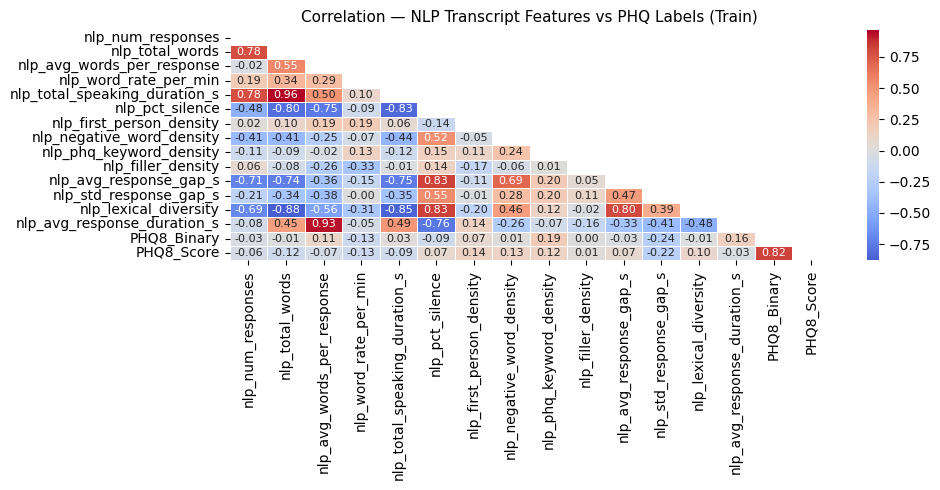


✓ Inspection complete. 448 usable features per participant.


In [23]:

# ── Feature count by modality ───────────────────────────────────────────────
modality_map = {
    "COVAREP"       : [c for c in feat_cols if c.startswith("covarep_")],
    "FORMANT"       : [c for c in feat_cols if c.startswith("formant_")],
    "CLNF_AUs"      : [c for c in feat_cols if c.startswith("au_")],
    "CLNF_pose"     : [c for c in feat_cols if c.startswith("pose_")],
    "CLNF_gaze"     : [c for c in feat_cols if c.startswith("gaze_")],
    "NLP_transcript": [c for c in feat_cols if c.startswith("nlp_")],
}

print("=" * 52)
print("  DAIC-WOZ — Final Feature Matrix Summary")
print("=" * 52)
print(f"  {'Modality':<20}  {'# Features':>10}")
print("-" * 52)
total_feat = 0
for mod, cols in modality_map.items():
    print(f"  {mod:<20}  {len(cols):>10}")
    total_feat += len(cols)
print("-" * 52)
print(f"  {'TOTAL':<20}  {total_feat:>10}")
print("=" * 52)

print(f"\nFinal array shapes:")
print(f"  X_train : {X_train.shape}   y_train_bin : {y_train_bin.shape}")
print(f"  X_val   : {X_val.shape}     y_val_bin   : {y_val_bin.shape}")
print(f"  X_test  : {X_test.shape}    y_test_bin  : {y_test_bin.shape}")

# ── Sample of scaled features (first 3 train rows, first 10 features) ────────
print(f"\nSample — first 3 train rows, first 10 features (scaled):")
df_sample = pd.DataFrame(X_train[:3, :10], columns=feat_cols[:10])
print(df_sample.round(3).to_string(index=False))

# ── Feature correlation heatmap (subset: NLP features vs binary label) ────────
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100

nlp_cols = modality_map["NLP_transcript"]
df_nlp   = merged.loc[train_idx, nlp_cols + ["PHQ8_Binary", "PHQ8_Score"]].copy()

fig, ax = plt.subplots(figsize=(10, 5))
corr = df_nlp.corr(numeric_only=True)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.4, annot_kws={"size": 8})
ax.set_title("Correlation — NLP Transcript Features vs PHQ Labels (Train)", fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n✓ Inspection complete. {total_feat} usable features per participant.")


## Section 9 — Save All Prepared Datasets to Disk

In [24]:

# ── 9-A  NumPy arrays (fast loading for model training) ───────────────────────
np.save(os.path.join(OUT_DIR, "daicwoz_X_train.npy"), X_train)
np.save(os.path.join(OUT_DIR, "daicwoz_X_val.npy"),   X_val)
np.save(os.path.join(OUT_DIR, "daicwoz_X_test.npy"),  X_test)

np.save(os.path.join(OUT_DIR, "daicwoz_y_train_bin.npy"),   y_train_bin)
np.save(os.path.join(OUT_DIR, "daicwoz_y_val_bin.npy"),     y_val_bin)
np.save(os.path.join(OUT_DIR, "daicwoz_y_test_bin.npy"),    y_test_bin)

np.save(os.path.join(OUT_DIR, "daicwoz_y_train_score.npy"), y_train_score)
np.save(os.path.join(OUT_DIR, "daicwoz_y_val_score.npy"),   y_val_score)
np.save(os.path.join(OUT_DIR, "daicwoz_y_test_score.npy"),  y_test_score)

# ── 9-B  Feature column names list ────────────────────────────────────────────
feat_col_path = os.path.join(OUT_DIR, "daicwoz_feature_cols.txt")
with open(feat_col_path, "w") as f:
    f.write("\n".join(feat_cols))

# ── 9-C  Full feature CSV (un-scaled, merged with labels — for EDA / SHAP) ───
full_csv_path = os.path.join(OUT_DIR, "daicwoz_features.csv")
merged_out = merged[["Participant_ID","split","PHQ8_Binary","PHQ8_Score","Gender"]].copy()
for i, col in enumerate(feat_cols):
    merged_out[col] = merged[feat_cols[i]].values
merged_out.to_csv(full_csv_path, index=False, float_format="%.6f")

# ── 9-D  Participant split mapping ────────────────────────────────────────────
split_map_path = os.path.join(OUT_DIR, "daicwoz_participant_splits.csv")
merged[["Participant_ID","split","PHQ8_Binary","PHQ8_Score","Gender"]].to_csv(
    split_map_path, index=False
)

# ── 9-E  Fitted scaler ────────────────────────────────────────────────────────
scaler_path = os.path.join(OUT_DIR, "daicwoz_scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

# ── Summary ───────────────────────────────────────────────────────────────────
import os as _os

print("=" * 60)
print("  Files saved to processed_data/")
print("=" * 60)
files_saved = [
    ("daicwoz_X_train.npy",           f"{X_train.shape}  float32"),
    ("daicwoz_X_val.npy",             f"{X_val.shape}  float32"),
    ("daicwoz_X_test.npy",            f"{X_test.shape}  float32"),
    ("daicwoz_y_train_bin.npy",       f"{y_train_bin.shape}  int32  (binary)"),
    ("daicwoz_y_val_bin.npy",         f"{y_val_bin.shape}  int32  (binary)"),
    ("daicwoz_y_test_bin.npy",        f"shape {y_test_bin.shape}"),
    ("daicwoz_y_train_score.npy",     f"{y_train_score.shape}  float32 (PHQ-8 score)"),
    ("daicwoz_y_val_score.npy",       f"{y_val_score.shape}  float32 (PHQ-8 score)"),
    ("daicwoz_y_test_score.npy",      f"shape {y_test_score.shape}"),
    ("daicwoz_feature_cols.txt",      f"{len(feat_cols)} feature names"),
    ("daicwoz_features.csv",          f"{len(merged_out)} rows x {len(merged_out.columns)} cols"),
    ("daicwoz_participant_splits.csv","participant -> split mapping"),
    ("daicwoz_scaler.pkl",            "StandardScaler fitted on train"),
]

for fname, desc in files_saved:
    fpath  = os.path.join(OUT_DIR, fname)
    exists = "✓" if _os.path.exists(fpath) else "✗"
    size   = f"{_os.path.getsize(fpath)/1024:.1f} KB" if _os.path.exists(fpath) else "N/A"
    print(f"  {exists}  {fname:<42} {size:<12}  {desc}")


  Files saved to processed_data/
  ✓  daicwoz_X_train.npy                        187.4 KB      (107, 448)  float32
  ✓  daicwoz_X_val.npy                          61.4 KB       (35, 448)  float32
  ✓  daicwoz_X_test.npy                         82.4 KB       (47, 448)  float32
  ✓  daicwoz_y_train_bin.npy                    0.5 KB        (107,)  int32  (binary)
  ✓  daicwoz_y_val_bin.npy                      0.3 KB        (35,)  int32  (binary)
  ✓  daicwoz_y_test_bin.npy                     0.5 KB        shape (47,)
  ✓  daicwoz_y_train_score.npy                  0.5 KB        (107,)  float32 (PHQ-8 score)
  ✓  daicwoz_y_val_score.npy                    0.3 KB        (35,)  float32 (PHQ-8 score)
  ✓  daicwoz_y_test_score.npy                   0.5 KB        shape (47,)
  ✓  daicwoz_feature_cols.txt                   8.6 KB        448 feature names
  ✓  daicwoz_features.csv                       794.5 KB      189 rows x 453 cols
  ✓  daicwoz_participant_splits.csv             3.1 KB     

## Section 10 — Quick Reload Snippet & Integration Guide

How to load these files in the model training notebook:

```python
import numpy as np, pickle

X_train = np.load("processed_data/daicwoz_X_train.npy")   # (n_train, n_features)
X_val   = np.load("processed_data/daicwoz_X_val.npy")
X_test  = np.load("processed_data/daicwoz_X_test.npy")

y_train = np.load("processed_data/daicwoz_y_train_bin.npy")  # binary labels
y_val   = np.load("processed_data/daicwoz_y_val_bin.npy")

# PHQ-8 regression target
y_train_score = np.load("processed_data/daicwoz_y_train_score.npy")

# Feature column names (for SHAP / interpretability)
with open("processed_data/daicwoz_feature_cols.txt") as f:
    feat_cols = f.read().splitlines()

# Scaler (for inverse-transforming predictions or new data)
with open("processed_data/daicwoz_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
```

### Feature groups for selective fusion
```python
covarep_idx  = [i for i,c in enumerate(feat_cols) if c.startswith("covarep_")]
formant_idx  = [i for i,c in enumerate(feat_cols) if c.startswith("formant_")]
au_idx       = [i for i,c in enumerate(feat_cols) if c.startswith("au_")]
pose_idx     = [i for i,c in enumerate(feat_cols) if c.startswith("pose_")]
gaze_idx     = [i for i,c in enumerate(feat_cols) if c.startswith("gaze_")]
nlp_idx      = [i for i,c in enumerate(feat_cols) if c.startswith("nlp_")]

X_audio_only = X_train[:, covarep_idx + formant_idx]   # for Whisper-branch ablation
X_text_only  = X_train[:, nlp_idx]                     # for BERT-branch ablation
```